# Decomposing Weights into Human Concepts — Report

## Motivation

Eigendecomposition decomposes `B[c]` per class, imposing **orthogonality** on eigenvectors within each class.
This is a hard constraint: if two digits share an edge-detector stroke, eigendecomposition must represent it
redundantly — once per class, rotated to avoid overlap. The result is "superposed" features that mix multiple
structural patterns into a single eigenvector.

CPD factorization avoids this by decomposing the *full* third-order tensor at once:
`B[c,i,j] ≈ Σ_r L[i,r] R[j,r] D[c,r]`. Each neuron `r` is shared across classes via `D`, so shared strokes
only need to be represented once. The orthogonality constraint is lifted entirely, and we are free to impose
more domain-relevant structural priors instead.


# Tensor Decomposition
*Thomas Dooms*

In tutorial 1, we decomposed the bilinear interaction tensor using eigendecomposition. This gives us interpretable features *per output class*, but there are some issues with this. The most important one is orthogonality; you might have overlapping structures in input space which behave differently. The second is somewhat of a consequence where eigendecompositions often yield "superposed" features; we might hope that a 6 decomposes into a few edge-detectors but that generally doesn't happen. If the model shares structure across classes, eigendecomposition can't see it.

Here we take a different approach. Instead of decomposing per class, we decompose the *full* third-order tensor into a set of shared **neurons**, each with explicit input patterns and output weights. The result is a set of interpretable building blocks that the model combines to classify digits.

### Setup

In [37]:
%load_ext autoreload
%autoreload 2

import math
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from pathlib import Path
from einops import einsum as ein

from image import Model, MNIST
from image.sparse import Model as Sparse
from kornia.augmentation import RandomGaussianNoise

device = "cuda:0"
train, test = MNIST(train=True, device=device), MNIST(train=False, device=device)

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RUN_LOG = RESULTS_DIR / "runs.log"

# Editorial palette
ACCENT      = "#C0392B"
ACCENT_SOFT = "#F1948A"
NEUTRAL     = "#9AA1A6"
SIM_BLUE    = "#2E86AB"
ACC_GREEN   = "#27AE60"
SPEC_ORANGE = "#E67E22"
GRID_GRAY   = "#EEEEEE"
INK         = "#1A1A1A"
INK_SOFT    = "#666666"

mpl.rcParams.update({
    "figure.dpi":              110,
    "savefig.dpi":              200,
    "savefig.bbox":            "tight",
    "savefig.facecolor":       "white",
    "figure.facecolor":        "white",
    "axes.facecolor":          "white",
    "font.family":             "sans-serif",
    "font.sans-serif":         ["Helvetica", "Inter", "Arial", "DejaVu Sans"],
    "font.size":               11,
    "mathtext.fontset":        "cm",
    "axes.titlelocation":      "left",
    "axes.titleweight":        "bold",
    "axes.titlesize":          13,
    "axes.titlecolor":         INK,
    "axes.titlepad":           14,
    "axes.labelcolor":         "#333",
    "axes.labelsize":          10,
    "axes.edgecolor":          "#B5B5B5",
    "axes.linewidth":          0.7,
    "axes.spines.top":         False,
    "axes.spines.right":       False,
    "xtick.color":             "#555",
    "ytick.color":             "#555",
    "xtick.labelsize":         9,
    "ytick.labelsize":         9,
    "xtick.major.size":        3,
    "ytick.major.size":        3,
    "xtick.major.width":       0.6,
    "ytick.major.width":       0.6,
    "legend.fontsize":         9.5,
    "legend.frameon":          False,
    "legend.handlelength":     2.2,
    "grid.color":              GRID_GRAY,
    "grid.linewidth":          0.5,
    "lines.markeredgewidth":   0.8,
})

CLASS_LABELS = [str(d) for d in range(10)]

# Auto-incrementing sequence so saved files list in notebook order.
_SAVE_SEQ = [0]
_SAVE_MANIFEST = []

# Route each saved artifact to a subfolder based on its filename prefix.
# Order matters — first matching prefix wins.
_FOLDER_PREFIXES = [
    ("baseline",      ("baseline_", "base_model_", "per_class_", "eigendec_")),
    ("experiment-A",  ("A_",)),
    ("experiment-B",  ("B_",)),
    ("experiment-C",  ("C_",)),
    ("experiment-D",  ("D_",)),
    ("experiment-E",  ("E_",)),
    ("experiment-F",  ("F_",)),
    ("diagnostics",   ("training_loss_",)),
    ("analysis",      ("summary", "experiment_comparison", "per_prior_", "complementary_")),
]


def _next_seq():
    _SAVE_SEQ[0] += 1
    return _SAVE_SEQ[0]


def _route(name):
    """Pick the subfolder for a filename. Returns Path relative to RESULTS_DIR."""
    for folder, prefixes in _FOLDER_PREFIXES:
        for prefix in prefixes:
            if name.startswith(prefix):
                return Path(folder)
    return Path(".")  # top-level results/


def save_fig(fig, name, scale=2):
    """Write a matplotlib figure to RESULTS_DIR/<experiment>/NN_name.png."""
    seq = _next_seq()
    sub = _route(name)
    dest_dir = RESULTS_DIR / sub
    dest_dir.mkdir(parents=True, exist_ok=True)
    out = dest_dir / f"{seq:02d}_{name}"
    fig.savefig(str(out), dpi=100 * scale, bbox_inches="tight", facecolor="white")
    rel = out.relative_to(RESULTS_DIR)
    _SAVE_MANIFEST.append((seq, "fig", str(rel)))
    print(f"[save_fig] {seq:02d}  {rel}")


def save_text(name, text):
    """Write text to RESULTS_DIR/<experiment>/NN_name."""
    seq = _next_seq()
    sub = _route(name)
    dest_dir = RESULTS_DIR / sub
    dest_dir.mkdir(parents=True, exist_ok=True)
    out = dest_dir / f"{seq:02d}_{name}"
    out.write_text(text)
    rel = out.relative_to(RESULTS_DIR)
    _SAVE_MANIFEST.append((seq, "text", str(rel)))
    print(f"[save_text] {seq:02d} {rel}")


def save_manifest():
    """Write a manifest of every artifact saved this session, grouped by folder."""
    lines = ["seq  kind  path"]
    for seq, kind, path in _SAVE_MANIFEST:
        lines.append(f"{seq:02d}   {kind:5s} {path}")
    (RESULTS_DIR / "00_manifest.txt").write_text("\n".join(lines) + "\n")
    print(f"Wrote {RESULTS_DIR / '00_manifest.txt'} ({len(_SAVE_MANIFEST)} entries).")


def _titleblock(fig, title, subtitle=None, y_title=0.985, gap_pt=22):
    """Title + optional subtitle at the figure's upper-left.
    The gap between title and subtitle is in points, so it stays visually
    constant regardless of figure height."""
    if title:
        fig.text(0.012, y_title, title, ha="left", va="top",
                 fontsize=14, fontweight="bold", color=INK)
    if subtitle:
        # Title font is 14pt; subtitle sits gap_pt below the title's BASELINE.
        fig_h_pt = fig.get_size_inches()[1] * 72
        y_sub = y_title - (14 + gap_pt) / fig_h_pt
        fig.text(0.012, y_sub, subtitle, ha="left", va="top",
                 fontsize=9.5, color=INK_SOFT, alpha=0.95)


def _style_cbar(cbar, label="weight"):
    """Apply the editorial style to a colorbar."""
    cbar.ax.tick_params(labelsize=8, color="#888")
    cbar.outline.set_edgecolor("#CCC")
    cbar.outline.set_linewidth(0.5)
    if label:
        cbar.set_label(label, fontsize=9, color="#555", labelpad=4)


def visualize(s, title="", subtitle="", nonneg=False, k=8,
              show_logits=True, save_name=None, height=None):
    """Render top-k components of a CPD as rows of l+r heatmaps, l-r heatmaps,
    and per-class D bars. Layout uses gridspec with a dedicated colorbar column."""
    with torch.no_grad():
        left  = s.left.abs()  if nonneg else s.left
        right = s.right.abs() if nonneg else s.right
        sigma_all = left.norm(dim=0) * right.norm(dim=0) * s.down.norm(dim=0)
        idx = sigma_all.argsort(descending=True)
        plus  = (left + right)[:, idx].cpu()
        minus = (left - right)[:, idx].cpu()
        down  = s.down.data[:, idx].cpu()
        sigma = sigma_all[idx].cpu()
        plus  = plus  / plus.norm(dim=0,  keepdim=True).clamp(min=1e-8)
        minus = minus / minus.norm(dim=0, keepdim=True).clamp(min=1e-8)

    plus_top, minus_top = plus[:, :k].numpy(), minus[:, :k].numpy()
    down_top, sigma_top = down[:, :k].numpy(), sigma[:k].numpy()
    zmax = max(abs(plus_top).max(), abs(minus_top).max())

    n_rows = 3 if show_logits else 2
    fig_w  = max(11.5, k * 1.35 + 2.4)
    fig_h  = (height / 100) if height else (7.6 if show_logits else 4.2)
    h_ratios = [1, 1, 1.18] if show_logits else [1, 1]

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(
        n_rows, k + 1,
        width_ratios=[1] * k + [0.06],
        height_ratios=h_ratios,
        hspace=0.34 if show_logits else 0.12,
        wspace=0.08,
        left=0.085, right=0.935,
        top=(0.88 if show_logits else 0.84) if title else 0.96,
        bottom=0.07,
    )

    axes = np.empty((n_rows, k), dtype=object)
    last_im = None
    for i in range(k):
        amax = int(np.argmax(np.abs(down_top[:, i])))
        sval = float(sigma_top[i])

        # Row 1: l + r
        ax = fig.add_subplot(gs[0, i]); axes[0, i] = ax
        last_im = ax.imshow(
            np.flipud(plus_top[:, i].reshape(28, 28)),
            cmap="RdBu_r", vmin=-zmax, vmax=zmax,
            aspect="equal", interpolation="nearest",
        )
        ax.set_title(f"σ {sval:.2f}  →{amax}",
                     fontsize=9, color="#444", pad=4, fontweight="normal")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

        # Row 2: l - r
        ax = fig.add_subplot(gs[1, i]); axes[1, i] = ax
        ax.imshow(
            np.flipud(minus_top[:, i].reshape(28, 28)),
            cmap="RdBu_r", vmin=-zmax, vmax=zmax,
            aspect="equal", interpolation="nearest",
        )
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)

        # Row 3: D_r per-class bars
        if show_logits:
            ax = fig.add_subplot(gs[2, i]); axes[2, i] = ax
            colors = [ACCENT if c == amax else NEUTRAL for c in range(10)]
            ax.bar(range(10), down_top[:, i], color=colors,
                   edgecolor="none", width=0.75)
            ax.axhline(0, color="#888", linewidth=0.4)
            ax.set_xticks(range(10))
            ax.set_xticklabels(CLASS_LABELS, fontsize=8)
            ax.tick_params(axis="y", labelsize=8)
            ax.grid(axis="y", color=GRID_GRAY, linewidth=0.5)
            ax.set_axisbelow(True)
            if i > 0:
                ax.set_yticklabels([])

    # Row labels — single source of truth, at axis-coord -0.30
    row_labels = ["l + r", "l − r"] + ([r"$D_r$"] if show_logits else [])
    for r_idx, label in enumerate(row_labels):
        axes[r_idx, 0].text(
            -0.32, 0.5, label, transform=axes[r_idx, 0].transAxes,
            ha="right", va="center",
            fontsize=12.5, fontweight="bold", color=INK,
        )

    # Colorbar in its dedicated gridspec column, spanning the two heatmap rows
    if last_im is not None:
        cbar_ax = fig.add_subplot(gs[:2, -1])
        cbar = fig.colorbar(last_im, cax=cbar_ax)
        _style_cbar(cbar, "weight")

    _titleblock(fig, title, subtitle)

    if save_name:
        save_fig(fig, save_name)
    plt.show()
    return fig


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 14.7MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 1.35MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 9.45MB/s]


### Training the original model

As in tutorial 1, we train a bilinear model with Gaussian noise augmentation to prevent overfitting on individual pixels.

In [38]:
model = Model.from_config(epochs=20).to(device)
train_history = model.fit(train, test, RandomGaussianNoise(std=0.4))


train/loss: 0.152, train/acc: 0.956, val/loss: 0.112, val/acc: 0.968: 100%|██████████████████████████████████████████████████████████████████████████| 20/20 [00:09<00:00,  2.15it/s]


### Base model training — loss and accuracy per epoch


[save_fig] 01  baseline/01_base_model_training.png


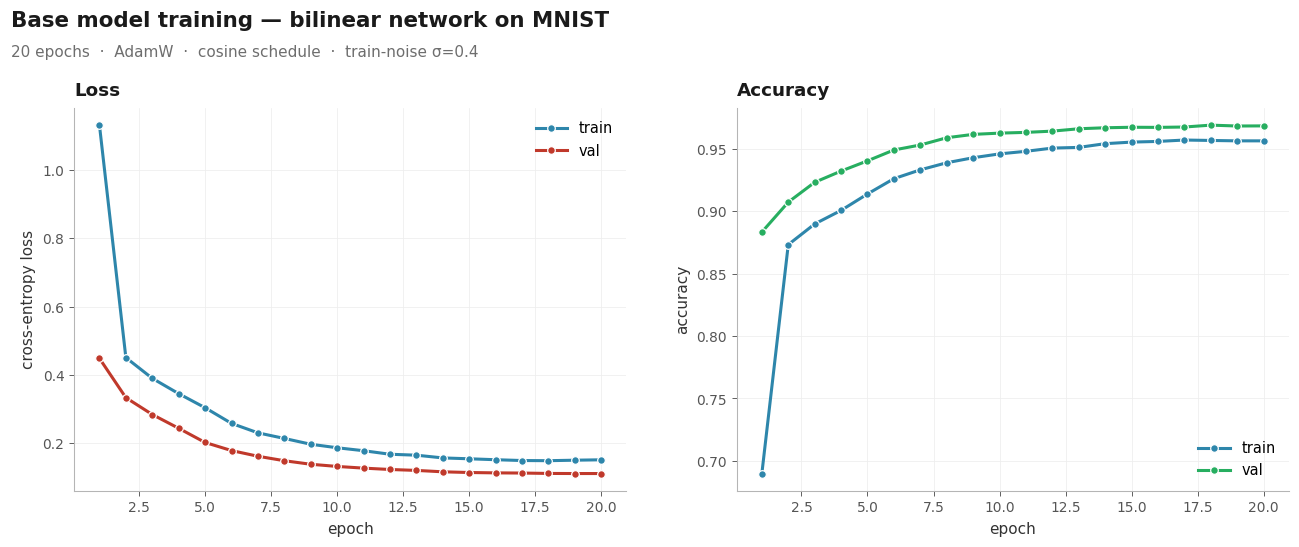

In [39]:
# Train/val curves from the bilinear base model's 20-epoch fit.
# Manual layout (no constrained_layout) so we can space the title block
# above the subplot titles without them colliding.
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.2))
epochs = np.arange(1, len(train_history) + 1)

# --- loss ---
ax = axes[0]
ax.plot(epochs, train_history["train/loss"], "-o", color=SIM_BLUE, linewidth=2.0,
        markersize=5, markeredgecolor="white", label="train")
ax.plot(epochs, train_history["val/loss"],   "-o", color=ACCENT,    linewidth=2.0,
        markersize=5, markeredgecolor="white", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Loss", fontsize=12, fontweight="bold", loc="left", pad=8, color=INK)
ax.grid(axis="both"); ax.set_axisbelow(True)
ax.legend(loc="upper right")

# --- accuracy ---
ax = axes[1]
ax.plot(epochs, train_history["train/acc"], "-o", color=SIM_BLUE,  linewidth=2.0,
        markersize=5, markeredgecolor="white", label="train")
ax.plot(epochs, train_history["val/acc"],   "-o", color=ACC_GREEN, linewidth=2.0,
        markersize=5, markeredgecolor="white", label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy", fontsize=12, fontweight="bold", loc="left", pad=8, color=INK)
ax.grid(axis="both"); ax.set_axisbelow(True)
ax.legend(loc="lower right")

# Reserve the top 20% of the figure for the title block.
fig.subplots_adjust(left=0.06, right=0.98, top=0.80, bottom=0.13, wspace=0.20)

# Figure-level title block, anchored top-left, with explicit gap.
fig.suptitle(
    "Base model training — bilinear network on MNIST",
    x=0.012, y=0.97, ha="left", va="top",
    fontsize=14, fontweight="bold", color=INK,
)
fig.text(
    0.012, 0.91,
    "20 epochs  ·  AdamW  ·  cosine schedule  ·  train-noise σ=0.4",
    ha="left", va="top", fontsize=10, color=INK_SOFT, alpha=0.95,
)

save_fig(fig, "base_model_training.png")
plt.show()


### From eigendecomposition to tensor decomposition

Recall that the bilinear model computes $\text{output}_c = \sum_{i,j} B_{c,i,j}\, x_i\, x_j$, where $B$ is the third-order interaction tensor. Eigendecomposition slices $B$ along the class axis and decomposes each slice independently.

We can instead factorize the *entire* tensor at once into a new bilinear layer:
$$B_{c,i,j} \approx \sum_{r=1}^{R} L_{i,r}\, R_{j,r}\, D_{c,r}$$

Each component $r$ is a **neuron** with three parts:
- $L_r \in \mathbb{R}^{784}$, the left input pattern
- $R_r \in \mathbb{R}^{784}$, the right input pattern  
- $D_r \in \mathbb{R}^{10}$, the output weights over classes

The neuron's activation on input $x$ is $(L_r^\top x)(R_r^\top x)$. Using the identity $ab = \tfrac{1}{4}(a+b)^2 - \tfrac{1}{4}(a-b)^2$, this becomes:
$$\tfrac{1}{4}\big((L_r + R_r)^\top x\big)^2 - \tfrac{1}{4}\big((L_r - R_r)^\top x\big)^2$$

So each neuron naturally decomposes into a **positive pattern** $L_r + R_r$ (matching it increases activation) and a **negative pattern** $L_r - R_r$ (matching it decreases activation). These are directly analogous to eigenvectors with positive and negative eigenvalues.

### Fitting the decomposition

We fit a new bilinear layer by maximizing the cosine similarity between the original interaction tensor and our approximation. The `Sparse` model stores $L$, $R$, and $D$ as learnable parameters and is optimized with Muon.

In [40]:
sparse = Sparse.from_config(rank=64).to(device)

optimizer = torch.optim.Muon(sparse.parameters(), lr=0.02, momentum=0.95)
scheduler = CosineAnnealingLR(optimizer, T_max=200)

loss_history = []
torch.set_grad_enabled(True)
for _ in (pbar := tqdm(range(200))):
    loss = 1 - sparse.similarity(model)
    loss_history.append({"total": loss.item(), "sim_loss": loss.item(), "reg": 0.0})

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    pbar.set_description(f"loss: {loss.item():.4f}")
torch.set_grad_enabled(False)
sparse.loss_history = loss_history

with torch.no_grad():
    orig_acc = (model(test.x).argmax(-1) == test.y).float().mean()
    sparse_acc = (sparse(test.x).argmax(-1) == test.y).float().mean()
    msg = f"Original: {orig_acc:.3f}, Sparse: {sparse_acc:.3f}"
    print(msg)
    save_text("baseline_accuracy.txt", msg + "\n")


loss: 0.0018: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 259.60it/s]


Original: 0.968, Sparse: 0.968
[save_text] 02 baseline/02_baseline_accuracy.txt


### Visualizing neurons

Each neuron has a positive pattern ($L_r + R_r$), a negative pattern ($L_r - R_r$), and output weights ($D_r$). The `decompose` method returns these normalized and sorted by importance (the product of the factor norms).

[save_fig] 03  baseline/03_baseline_grid.png


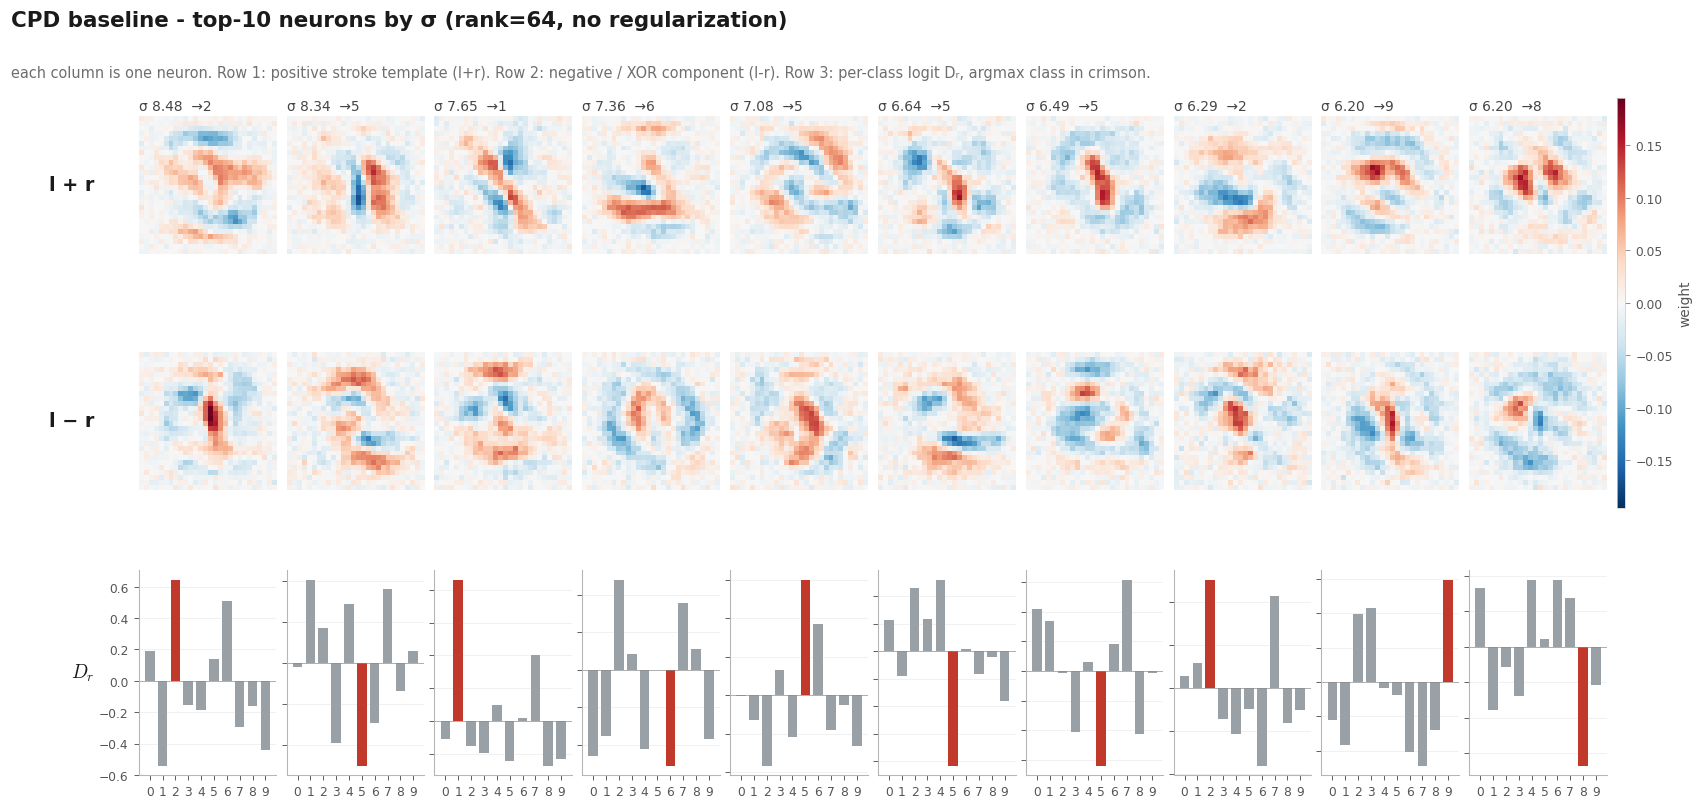

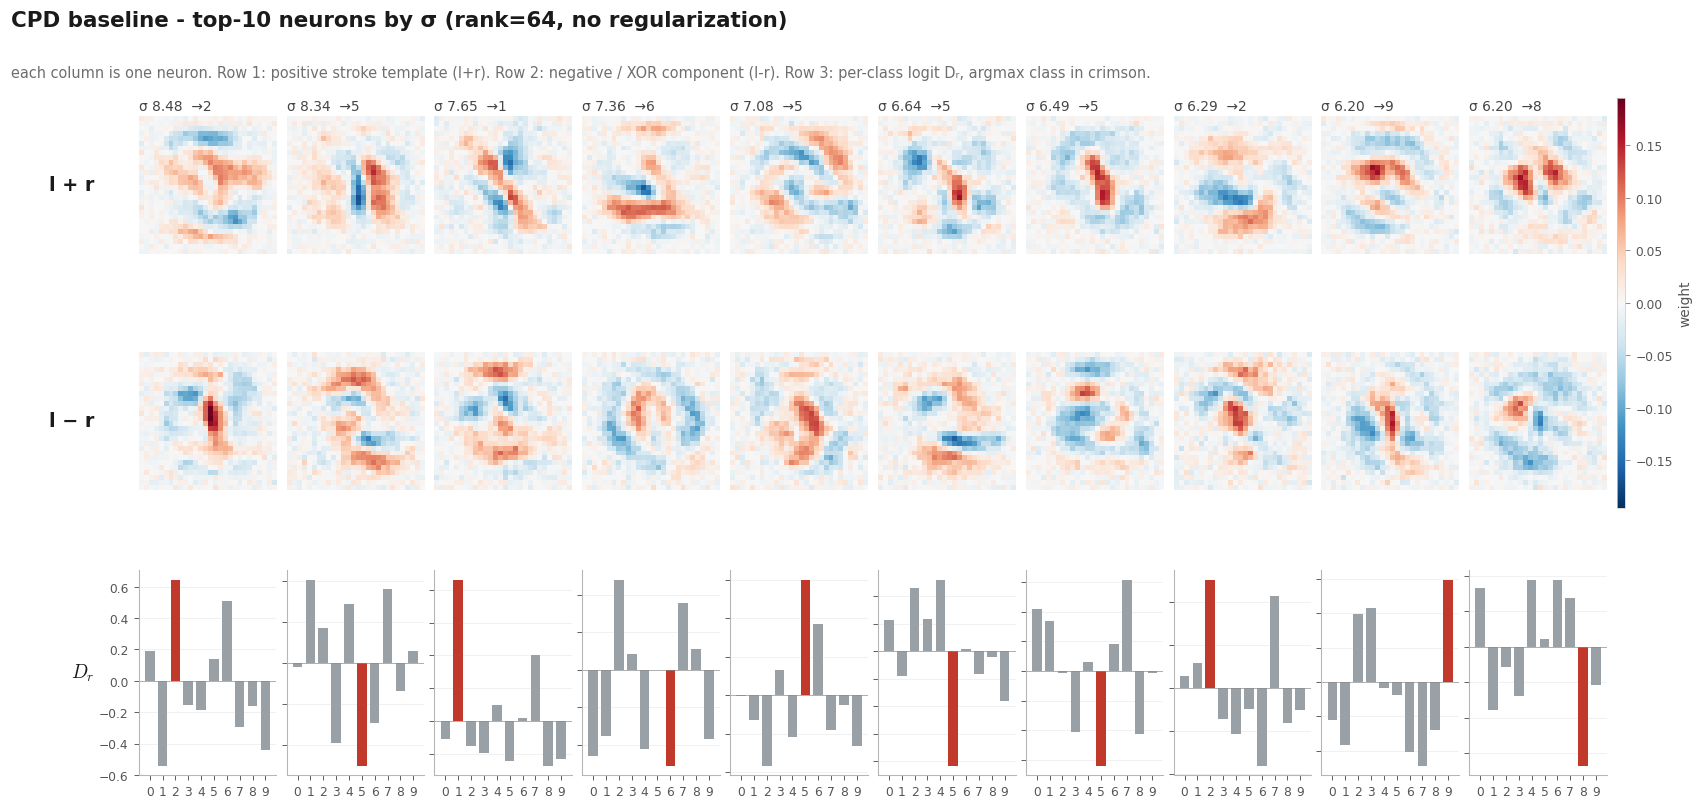

In [41]:
visualize(
    sparse,
    title="CPD baseline - top-10 neurons by σ (rank=64, no regularization)",
    subtitle=("each column is one neuron. Row 1: positive stroke template (l+r). "
              "Row 2: negative / XOR component (l-r). Row 3: per-class logit Dᵣ, "
              "argmax class in crimson."),
    k=10,
    save_name="baseline_grid.png",
)


[save_fig] 04  baseline/04_baseline_sigma.png


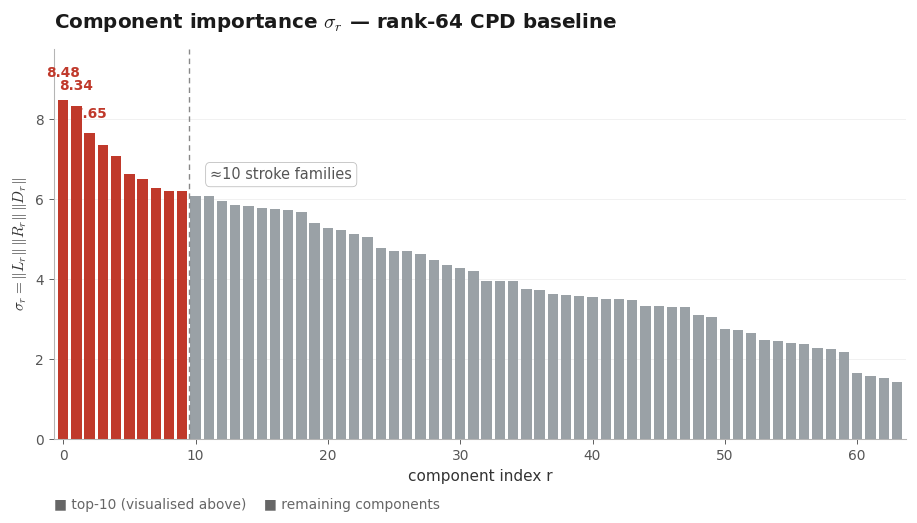

In [42]:
_, _, _, sigma = sparse.decompose()
sigma_np = sigma.cpu().numpy()
top_k = 10
elbow = 10
bar_colors = [ACCENT if i < top_k else NEUTRAL for i in range(len(sigma_np))]

fig, ax = plt.subplots(figsize=(10.0, 4.6))
ax.bar(range(len(sigma_np)), sigma_np, color=bar_colors, edgecolor="none", width=0.78)

# Numeric labels on the top-3 components, sitting clearly above each bar.
for i in range(3):
    ax.annotate(
        f"{float(sigma_np[i]):.2f}",
        xy=(i, float(sigma_np[i])), xytext=(0, 15) if i == 0 else (0, 10),
        textcoords="offset points",
        ha="center", fontsize=9, color=ACCENT, fontweight="bold",
    )

ax.axvline(elbow - 0.5, color="#888", linewidth=0.9, linestyle=(0, (4, 3)))
ax.annotate(
    f"≈{elbow} stroke families",
    xy=(elbow - 0.5, float(sigma_np.max()) * 0.78),
    xytext=(14, 0), textcoords="offset points",
    fontsize=9.5, color="#555", va="center",
    bbox=dict(boxstyle="round,pad=0.32", fc="white", ec="#BBB", lw=0.5),
)

# Y-axis headroom so the top-bar annotations sit above the bars, not into the title.
ax.set_ylim(0, float(sigma_np.max()) * 1.15)

ax.set_title(r"Component importance $\sigma_r$ — rank-64 CPD baseline")
ax.set_xlabel("component index r")
ax.set_ylabel(r"$\sigma_r = \|L_r\|\,\|R_r\|\,\|D_r\|$")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.margins(x=0.005)

ax.text(0.0, -0.18,
        "■ top-10 (visualised above)    ■ remaining components",
        transform=ax.transAxes, fontsize=9, color=INK_SOFT)

save_fig(fig, "baseline_sigma.png")
plt.show()


### Baseline diagnostics: |D| neuron-class assignment


[save_fig] 05  baseline/05_baseline_D_heatmap.png


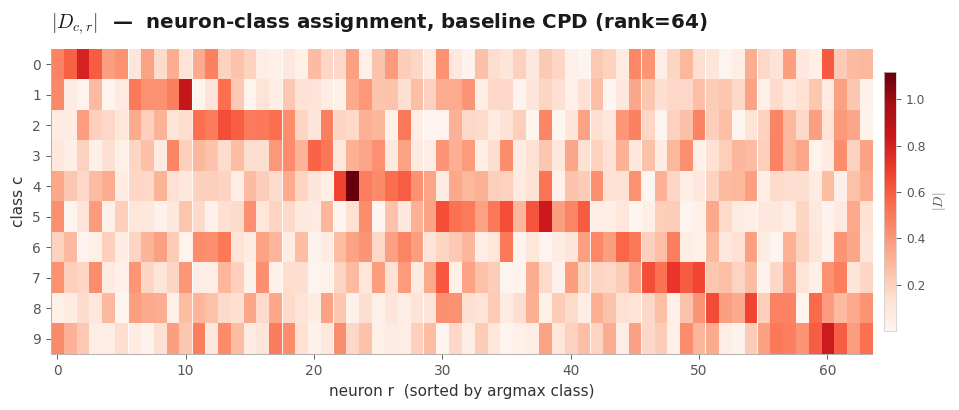

In [43]:
# |D[c, r]| heatmap: rows = classes, cols = CPD neurons sorted by argmax class.
# Blocky structure ⇒ specialized neurons. Smeared rows/cols ⇒ polysemanticity.
with torch.no_grad():
    D = sparse.down.data.abs().cpu().numpy()

argmax_class = D.argmax(axis=0)
col_order    = np.argsort(argmax_class, kind="stable")
D_sorted     = D[:, col_order]

fig, ax = plt.subplots(figsize=(11.5, 3.6))
im = ax.imshow(D_sorted, aspect="auto", cmap="Reds", interpolation="nearest")
ax.set_xlabel("neuron r  (sorted by argmax class)")
ax.set_ylabel("class c")
ax.set_yticks(range(10))
ax.set_yticklabels(CLASS_LABELS)
ax.set_title(r"$|D_{c,r}|$  —  neuron-class assignment, baseline CPD (rank=64)")

# Class boundaries: vertical separators where argmax changes
sorted_cls = argmax_class[col_order]
for i in range(1, len(sorted_cls)):
    if sorted_cls[i] != sorted_cls[i - 1]:
        ax.axvline(i - 0.5, color="white", linewidth=0.7, alpha=0.85)

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.012, aspect=22)
cbar.set_label(r"$|D|$", fontsize=9, color="#555")
cbar.ax.tick_params(labelsize=8)
cbar.outline.set_edgecolor("#CCC")
cbar.outline.set_linewidth(0.5)

save_fig(fig, "baseline_D_heatmap.png")
plt.show()


### Per-class test accuracy: original model vs CPD baseline


[save_fig] 06  baseline/06_per_class_accuracy.png


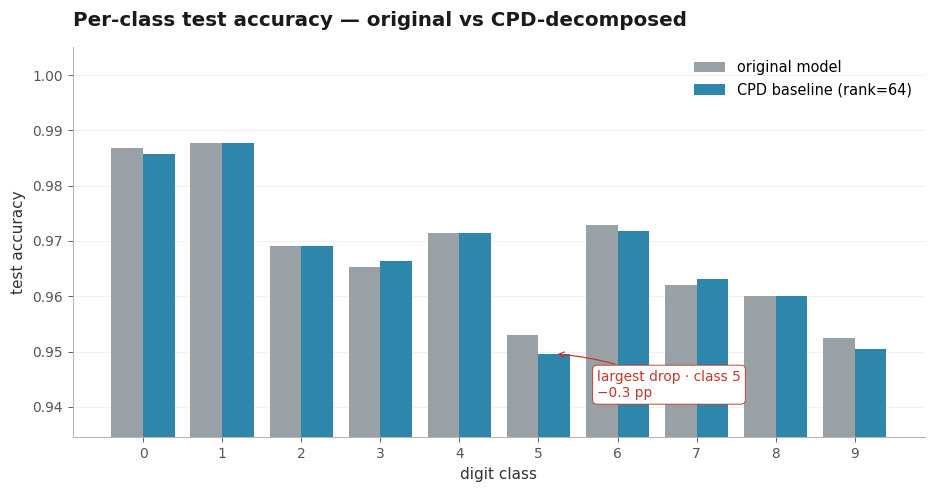

In [44]:
with torch.no_grad():
    pred_orig = model(test.x).argmax(-1)
    pred_cpd  = sparse(test.x).argmax(-1)
    y         = test.y

    per_class_orig, per_class_cpd, support = [], [], []
    for c in range(10):
        mask = (y == c)
        per_class_orig.append((pred_orig[mask] == c).float().mean().item())
        per_class_cpd.append( (pred_cpd[mask]  == c).float().mean().item())
        support.append(int(mask.sum().item()))

x_pos = np.arange(10); w = 0.4

fig, ax = plt.subplots(figsize=(10.0, 4.6))
ax.bar(x_pos - w/2, per_class_orig, width=w, color=NEUTRAL,  edgecolor="none",
       label="original model")
ax.bar(x_pos + w/2, per_class_cpd,  width=w, color=SIM_BLUE, edgecolor="none",
       label="CPD baseline (rank=64)")

# Largest gap callout
gaps = [o - c for o, c in zip(per_class_orig, per_class_cpd)]
worst = int(np.argmax(gaps))
ax.annotate(
    f"largest drop · class {worst}\n−{gaps[worst]*100:.1f} pp",
    xy=(worst + w/2, per_class_cpd[worst]), xytext=(28, -28),
    textcoords="offset points", fontsize=9, color=ACCENT,
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=0.8,
                    connectionstyle="arc3,rad=0.1"),
    bbox=dict(boxstyle="round,pad=0.32", fc="white", ec=ACCENT, lw=0.6),
)

ax.set_xticks(x_pos); ax.set_xticklabels(CLASS_LABELS)
ax.set_xlabel("digit class"); ax.set_ylabel("test accuracy")
y_lo = min(per_class_orig + per_class_cpd) - 0.015
ax.set_ylim(max(0.0, y_lo), 1.005)
ax.set_title("Per-class test accuracy — original vs CPD-decomposed")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="upper right")
save_fig(fig, "per_class_accuracy.png")
plt.show()


### Eigendecomposition vs CPD: same digit, two methods


top-1 relative residual ||B[c] - rank1||/||B[c]||  (lower = better):
  eigendec mean: 0.826
  CPD      mean: 2.158
[save_fig] 07  baseline/07_eigendec_vs_cpd.png


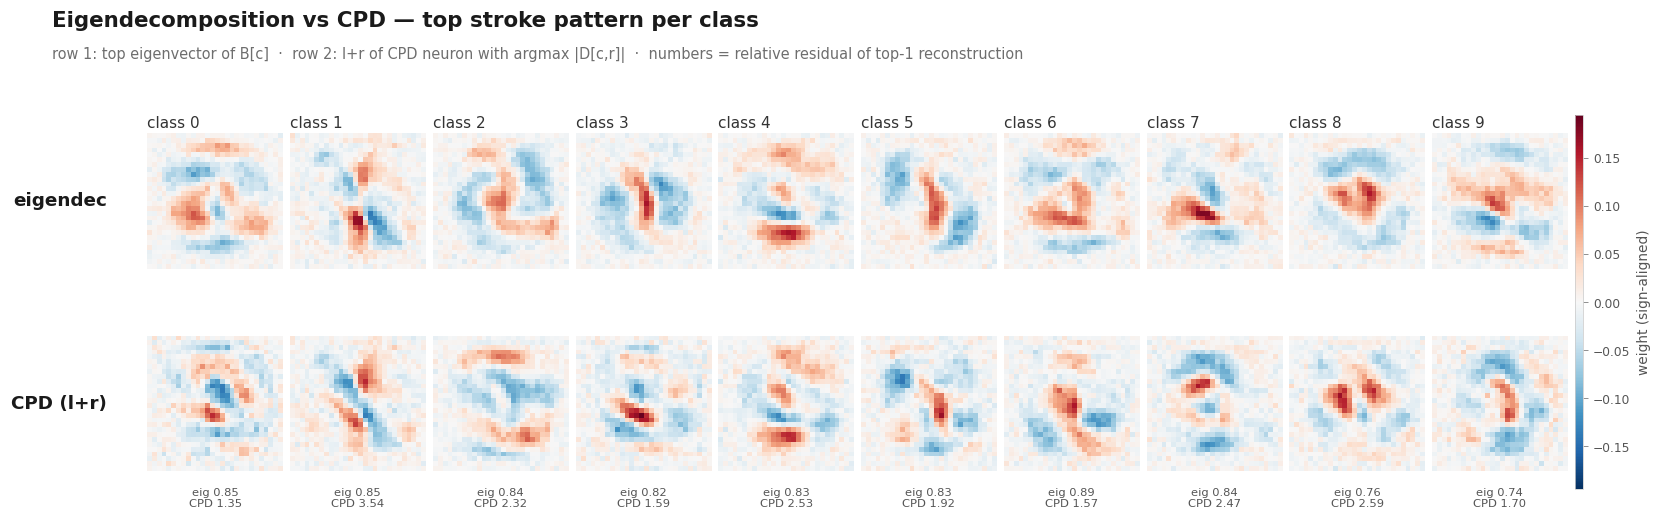

In [45]:
# For each class c, compare the top eigenvector of B[c] with the CPD neuron
# whose D-row is most class-c-specialized.
with torch.no_grad():
    wl, wr = model.w_lr[0].unbind()
    wl_e, wr_e = wl @ model.w_e, wr @ model.w_e
    B = ein(model.w_u, wl_e, wr_e, "c o, o i, o j -> c i j")
    B = 0.5 * (B + B.mT)

    top_eigvecs = []
    for c in range(10):
        eigvals, eigvecs = torch.linalg.eigh(B[c])
        idx_max = int(eigvals.abs().argmax())
        v = eigvecs[:, idx_max].cpu().numpy()
        v = v if v[np.argmax(np.abs(v))] >= 0 else -v
        top_eigvecs.append(v)

    D = sparse.down.data.cpu().numpy()
    L = sparse.left.data.cpu().numpy()
    R = sparse.right.data.cpu().numpy()
    cpd_patterns = []
    for c in range(10):
        r_star = int(np.argmax(np.abs(D[c])))
        p = L[:, r_star] + R[:, r_star]
        p = p / (np.linalg.norm(p) + 1e-8)
        p = p if p[np.argmax(np.abs(p))] >= 0 else -p
        cpd_patterns.append(p)

zmax = max(
    max(np.abs(v).max() for v in top_eigvecs),
    max(np.abs(p).max() for p in cpd_patterns),
)

# Taller figure + lower gs.top so the title block sits clearly above the class labels.
fig = plt.figure(figsize=(15.0, 5.0))
gs = fig.add_gridspec(
    2, 11,
    width_ratios=[1] * 10 + [0.06],
    hspace=0.18, wspace=0.06,
    left=0.07, right=0.94, top=0.78, bottom=0.10,
)

axes_eig = [fig.add_subplot(gs[0, c]) for c in range(10)]
axes_cpd = [fig.add_subplot(gs[1, c]) for c in range(10)]

last_im = None
for c in range(10):
    for r_idx, (axis_list, vec) in enumerate(((axes_eig, top_eigvecs[c]),
                                              (axes_cpd, cpd_patterns[c]))):
        ax = axis_list[c]
        last_im = ax.imshow(np.flipud(vec.reshape(28, 28)),
                            cmap="RdBu_r", vmin=-zmax, vmax=zmax,
                            aspect="equal", interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)
        if r_idx == 0:
            ax.set_title(f"class {c}", fontsize=10, color="#333", pad=4,
                         fontweight="normal")

axes_eig[0].text(-0.30, 0.5, "eigendec", transform=axes_eig[0].transAxes,
                 ha="right", va="center", fontsize=12,
                 fontweight="bold", color=INK)
axes_cpd[0].text(-0.30, 0.5, "CPD (l+r)", transform=axes_cpd[0].transAxes,
                 ha="right", va="center", fontsize=12,
                 fontweight="bold", color=INK)


# Quantitative residual: how well each top-1 component reconstructs B[c] alone.
# For eigendec, the best rank-1 approx of B[c] is λ_max·v·vᵀ (analytic).
# For CPD, the comparable rank-1 chunk is D[c,r*] · L[:,r*] ⊗ R[:,r*] for r* = argmax|D[c,r]|.
with torch.no_grad():
    eig_residuals = []
    cpd_residuals = []
    for c in range(10):
        B_c = B[c]
        b_norm = B_c.norm().item() + 1e-8

        eigvals, eigvecs = torch.linalg.eigh(B_c)
        k = int(eigvals.abs().argmax())
        rank1_eig = eigvals[k] * torch.outer(eigvecs[:, k], eigvecs[:, k])
        eig_residuals.append(((B_c - rank1_eig).norm() / b_norm).item())

        r_star = int(np.argmax(np.abs(D[c])))
        l_r = torch.tensor(L[:, r_star], device=B_c.device)
        r_r = torch.tensor(R[:, r_star], device=B_c.device)
        rank1_cpd = D[c, r_star] * 0.5 * (torch.outer(l_r, r_r) + torch.outer(r_r, l_r))
        cpd_residuals.append(((B_c - rank1_cpd).norm() / b_norm).item())

# Annotate per-class residuals below each column.
for c in range(10):
    axes_cpd[c].text(
        0.5, -0.12,
        f"eig {eig_residuals[c]:.2f}\nCPD {cpd_residuals[c]:.2f}",
        transform=axes_cpd[c].transAxes,
        ha="center", va="top", fontsize=7.5, color="#555",
    )

eig_mean = sum(eig_residuals) / len(eig_residuals)
cpd_mean = sum(cpd_residuals) / len(cpd_residuals)
print(f"top-1 relative residual ||B[c] - rank1||/||B[c]||  (lower = better):")
print(f"  eigendec mean: {eig_mean:.3f}")
print(f"  CPD      mean: {cpd_mean:.3f}")

cbar_ax = fig.add_subplot(gs[:, -1])
cbar = fig.colorbar(last_im, cax=cbar_ax)
_style_cbar(cbar, "weight (sign-aligned)")

# Explicit title block positioning (not _titleblock, because this figure is short
# enough that the auto-gap formula would push the subtitle into the class labels).
fig.text(0.012, 0.97,
         "Eigendecomposition vs CPD — top stroke pattern per class",
         ha="left", va="top", fontsize=14, fontweight="bold", color=INK)
fig.text(0.012, 0.905,
         "row 1: top eigenvector of B[c]  ·  row 2: l+r of CPD neuron with argmax |D[c,r]|  ·  numbers = relative residual of top-1 reconstruction",
         ha="left", va="top", fontsize=9.5, color=INK_SOFT, alpha=0.95)

save_fig(fig, "eigendec_vs_cpd.png")
plt.show()


### Exercises

The goal of this part is to implement a decomposition that is more in line with our requirements. This is where you try to find what kinds of priors and structure work well. The code above provides a skeleton with the essentials: the `Sparse` model, the reconstruction loop, and the visualization. There's no right answer and this is a hard task to get right.

## Phase 3: Alternative Decompositions

### Results Tracking Setup

In [46]:
results = {}
RUN_LOG.write_text("")

def _entropy_specialization(down):
    """Per-neuron 1 - H(p)/log(C) where p_c = |D[c,r]| / sum_c |D[c,r]|.

    0 = uniform across classes, 1 = one-hot.
    """
    p = down.abs() / down.abs().sum(dim=0, keepdim=True).clamp(min=1e-12)
    H = -(p * (p.clamp(min=1e-12)).log()).sum(dim=0)  # per-neuron entropy in nats
    C = down.shape[0]
    return (1 - H / math.log(C)).mean().item()

def log_result(name, sparse_model, base_model, test_data, notes=""):
    with torch.no_grad():
        sim = sparse_model.similarity(base_model).item()
        acc = (sparse_model(test_data.x).argmax(-1) == test_data.y).float().mean().item()
        plus, minus, down, sigma = sparse_model.decompose()
        spec_maxsum = (down.abs().max(dim=0).values / down.abs().sum(dim=0).clamp(min=1e-8)).mean().item()
        spec_entropy = _entropy_specialization(down)
    results[name] = {"similarity": round(sim,4), "accuracy": round(acc,4),
                     "specialization": round(spec_maxsum,4),
                     "spec_entropy": round(spec_entropy,4),
                     "notes": notes}
    line = f"{name}: sim={sim:.4f}  acc={acc:.4f}  spec={spec_maxsum:.4f}  spec_H={spec_entropy:.4f}"
    print(line)
    with RUN_LOG.open("a") as f:
        f.write(line + "\n")


In [47]:
log_result('baseline_rank64', sparse, model, test, notes='CPD baseline, no regularization')

baseline_rank64: sim=0.9982  acc=0.9679  spec=0.2380  spec_H=0.1142


### Shared Training Helper

A single `train_sparse` function handles all experiments via flags and weights.

In [48]:
def train_sparse(rank=64, l1_input=0.0, l1_output=0.0, sym_weight=0.0,
                 steps=200, lr=0.02, seed=42,
                 eval_data=None, eval_every=10):
    """Fit a Sparse CPD approximating ``model``'s bilinear interaction tensor.

    Each prior is an additive penalty on the cosine-similarity loss:
        l1_input    -> ||L||_1 + ||R||_1     (sparse input patterns)
        l1_output   -> ||D||_1               (sparse output / specialization)
        sym_weight  -> ||L - R||_F           (symmetric, no XOR component)

    If `eval_data` is provided, val_acc is recorded every `eval_every` steps
    (alongside the training loss components).

    Returns the trained Sparse model. Loss history is attached as
    `s.loss_history` (list of {"step", "total", "sim_loss", "reg",
    optionally "val_acc"} per step).
    """
    torch.set_grad_enabled(True)
    s = Sparse.from_config(rank=rank, seed=seed).to(device)
    optimizer = torch.optim.Muon(s.parameters(), lr=lr, momentum=0.95)
    scheduler = CosineAnnealingLR(optimizer, T_max=steps)

    with torch.no_grad():
        wl, wr = model.w_lr[0].unbind()
        wl_e, wr_e = wl @ model.w_e, wr @ model.w_e
        target = ein(model.w_u, wl_e, wr_e, "c o, o i, o j -> c i j")
        target = 0.5 * (target + target.mT)
        target_norm = target.norm()

    history = []
    for step in (pbar := tqdm(range(steps), leave=False)):
        t = ein(s.down, s.left, s.right, "c r, i r, j r -> c i j")
        t = 0.5 * (t + t.mT)
        assert t.shape == target.shape, f"pred shape {t.shape} != target shape {target.shape}"
        sim = ein(target, t, "c i j, c i j ->") / (target_norm * t.norm().clamp(min=1e-8))
        sim_loss = 1 - sim
        loss = sim_loss
        reg = 0.0
        if l1_input  > 0:
            term = l1_input  * (s.left.abs().mean() + s.right.abs().mean())
            loss = loss + term; reg += term.item()
        if l1_output > 0:
            term = l1_output * s.down.abs().mean()
            loss = loss + term; reg += term.item()
        if sym_weight > 0:
            term = sym_weight * (s.left - s.right).norm()
            loss = loss + term; reg += term.item()

        entry = {"step": step,
                 "total": loss.item(),
                 "sim_loss": sim_loss.item(),
                 "reg": reg}

        # Periodic eval on held-out data — captures classification fidelity over training.
        if eval_data is not None and (step % eval_every == 0 or step == steps - 1):
            with torch.no_grad():
                preds = s(eval_data.x).argmax(-1)
                entry["val_acc"] = (preds == eval_data.y).float().mean().item()

        history.append(entry)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        pbar.set_description(f"loss:{loss.item():.4f}")

    torch.set_grad_enabled(False)
    s.loss_history = history
    return s


In [49]:
# Invariant: the explicit einsum in train_sparse must agree with the model
# API to float tolerance.
def _manual_similarity(s, m):
    with torch.no_grad():
        wl, wr = m.w_lr[0].unbind()
        wl_e, wr_e = wl @ m.w_e, wr @ m.w_e
        tgt = ein(m.w_u, wl_e, wr_e, "c o, o i, o j -> c i j")
        tgt = 0.5 * (tgt + tgt.mT)
        pred = s.tensor()
        return (ein(tgt, pred, "c i j, c i j ->") / (tgt.norm() * pred.norm())).item()

_test_s = Sparse.from_config(rank=8, seed=42).to(device)
_lib = _test_s.similarity(model).item()
_man = _manual_similarity(_test_s, model)
assert abs(_lib - _man) < 1e-5, f"similarity paths disagree: api={_lib}  manual={_man}"
print(f"similarity ok: api={_lib:.6f}  manual={_man:.6f}  diff={abs(_lib-_man):.2e}")


similarity ok: api=-0.000275  manual=-0.000275  diff=0.00e+00


### Experiment B: L1 Sparsity on Output Weights (Neuron Specialization)

**Mathematical motivation**: In the CPD formula $B_{c,i,j} \approx \sum_r L_{i,r}\,R_{j,r}\,D_{c,r}$, the matrix $D \in \mathbb{R}^{10 \times R}$ controls how strongly each neuron $r$ votes for each class $c$. Without regularization the optimizer can spread weight across all 10 classes simultaneously, yielding polysemantic neurons. Adding $\lambda_B \|D\|_1$ directly penalizes multi-class participation — each neuron is pushed to commit to a single class. This directly optimizes the *short* desideratum: a description is short if you only need to inspect 1–2 neurons per digit.

**Hypothesis**: L1 on $D$ will increase neuron specialization (measured by max/sum ratio of logit magnitudes) with minimal accuracy degradation.


In [50]:
print("=== Experiment B: L1 on output weights (D) ===")
sparse_b = {}
for l1w in [0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]:
    print(f"  l1_output={l1w}")
    s = train_sparse(l1_output=l1w, eval_data=test, eval_every=10)
    log_result(f'B_L1_output_{l1w}', s, model, test, notes=f'L1 on D, λ={l1w}')
    sparse_b[l1w] = s


=== Experiment B: L1 on output weights (D) ===
  l1_output=0.001


B_L1_output_0.001: sim=0.9982  acc=0.9679  spec=0.2390  spec_H=0.1158
  l1_output=0.01


B_L1_output_0.01: sim=0.9981  acc=0.9680  spec=0.2492  spec_H=0.1318
  l1_output=0.03


B_L1_output_0.03: sim=0.9980  acc=0.9680  spec=0.2702  spec_H=0.1664
  l1_output=0.1


B_L1_output_0.1: sim=0.9979  acc=0.9681  spec=0.3122  spec_H=0.2355
  l1_output=0.3


B_L1_output_0.3: sim=0.9975  acc=0.9683  spec=0.3730  spec_H=0.3280
  l1_output=1.0


B_L1_output_1.0: sim=0.9967  acc=0.9683  spec=0.4743  spec_H=0.4629
  l1_output=3.0


B_L1_output_3.0: sim=0.9958  acc=0.9678  spec=0.5477  spec_H=0.5547
  l1_output=10.0


B_L1_output_10.0: sim=0.9949  acc=0.9674  spec=0.5863  spec_H=0.5950


Best B: l1_output=10.0 -> spec=0.5863
[save_fig] 08  experiment-B/08_B_best.png


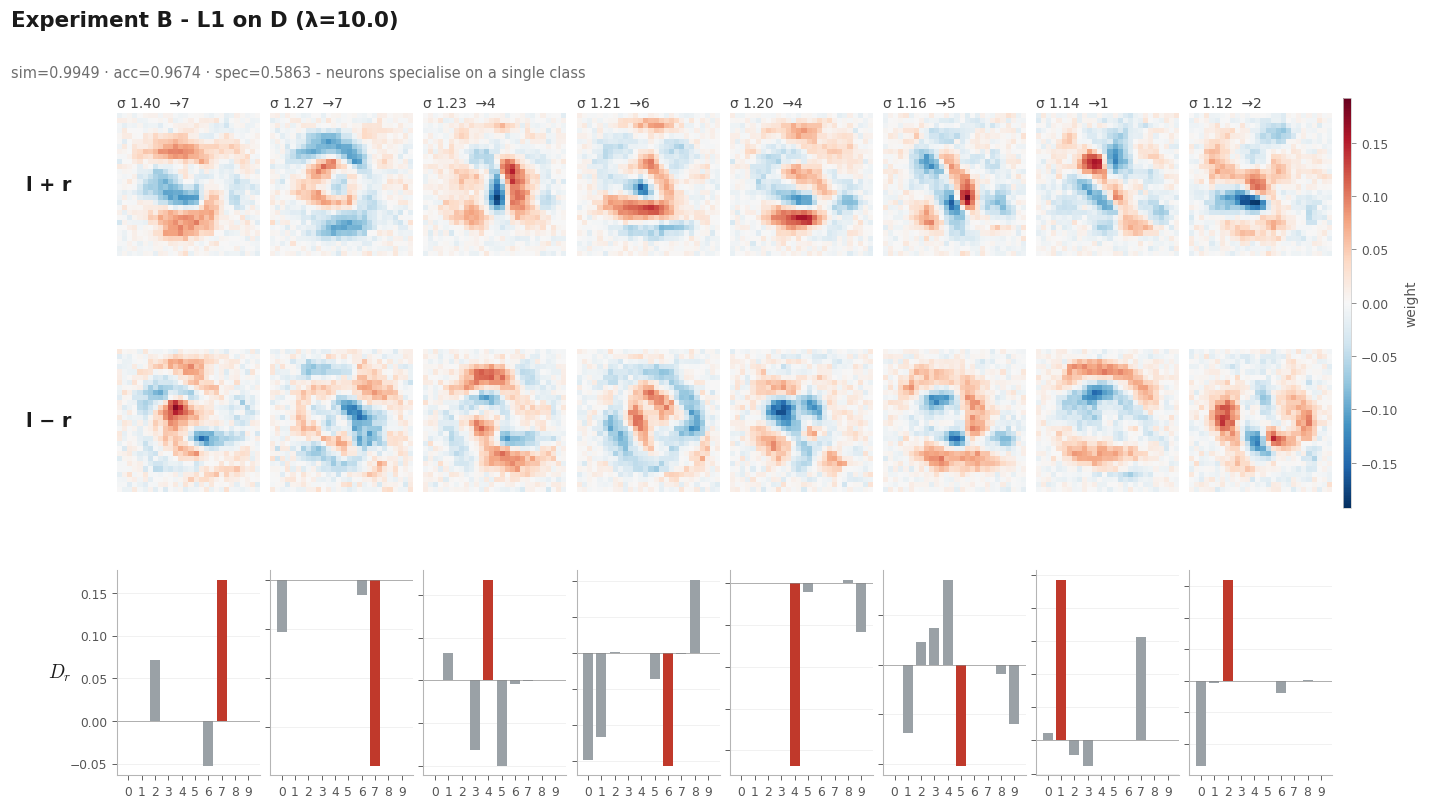

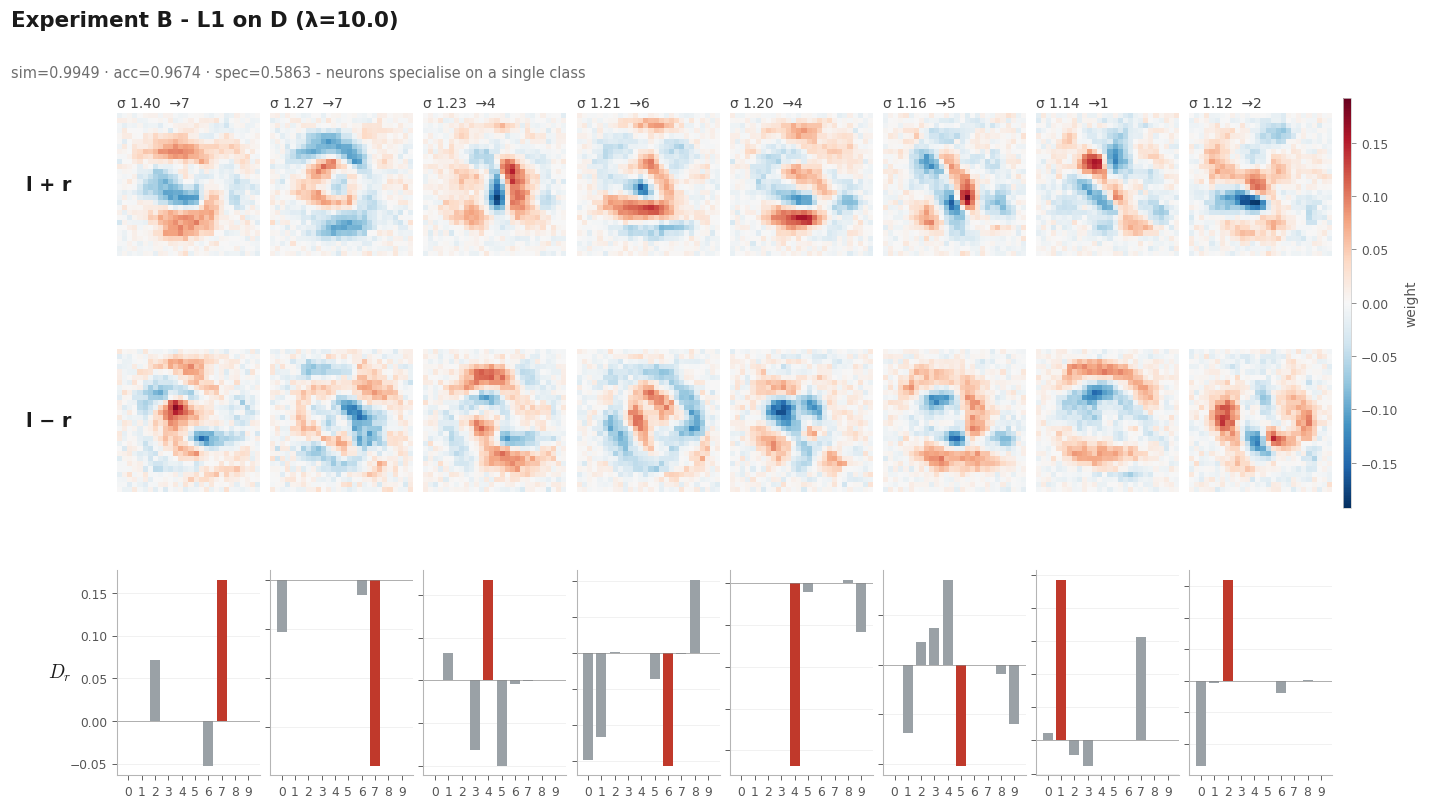

In [51]:
best_b = max(sparse_b, key=lambda k: results[f'B_L1_output_{k}']['specialization']
             if results[f'B_L1_output_{k}']['accuracy'] > 0.85 else -1)
res_b = results[f'B_L1_output_{best_b}']
print(f"Best B: l1_output={best_b} -> spec={res_b['specialization']:.4f}")
visualize(
    sparse_b[best_b],
    title=f"Experiment B - L1 on D (λ={best_b})",
    subtitle=(f"sim={res_b['similarity']:.4f} · acc={res_b['accuracy']:.4f} · "
              f"spec={res_b['specialization']:.4f} - neurons specialise on a single class"),
    save_name="B_best.png",
)


### Experiment B - λ sweep (all metrics)


[save_fig] 09  experiment-B/09_B_lambda_sweep.png


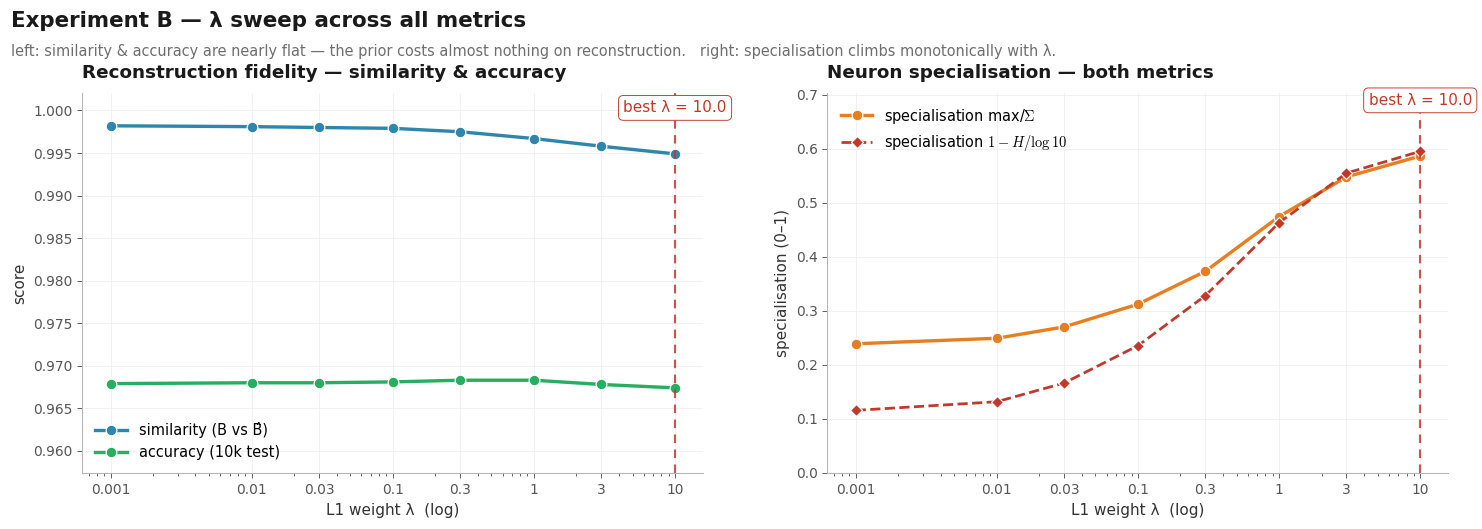

In [52]:
lambdas_b = sorted(sparse_b.keys())
sims_b    = [results[f'B_L1_output_{l}']['similarity']     for l in lambdas_b]
accs_b    = [results[f'B_L1_output_{l}']['accuracy']       for l in lambdas_b]
specs_b   = [results[f'B_L1_output_{l}']['specialization'] for l in lambdas_b]
specsH_b  = [results[f'B_L1_output_{l}']['spec_entropy']   for l in lambdas_b]

# Two panels share the log-x axis but have separate y-scales —
# similarity/accuracy live near 1.0, specialisation lives in [0, 1).
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharex=True)

# ---------- Panel 1: similarity + accuracy (zoomed y) ----------
ax = axes[0]
ax.plot(lambdas_b, sims_b, "-o",  color=SIM_BLUE,  linewidth=2.2, markersize=7,
        markeredgecolor="white", label="similarity (B vs B̂)")
ax.plot(lambdas_b, accs_b, "-o",  color=ACC_GREEN, linewidth=2.2, markersize=7,
        markeredgecolor="white", label="accuracy (10k test)")

# Auto-zoom y to where the data lives, with 1-2% headroom
y_lo = min(sims_b + accs_b) - 0.01
ax.set_ylim(y_lo, 1.002)

ax.axvline(best_b, color=ACCENT, linewidth=1.4, linestyle=(0, (4, 3)), alpha=0.85)
ax.annotate(
    f"best λ = {best_b}",
    xy=(best_b, 1.002 - (1.002 - y_lo) * 0.05),
    ha="center", fontsize=10, color=ACCENT,
    bbox=dict(boxstyle="round,pad=0.32", fc="white", ec=ACCENT, lw=0.6),
)

ax.set_xscale("log")
ax.set_xticks(lambdas_b)
ax.set_xticklabels([f"{l:g}" for l in lambdas_b], fontsize=9)
ax.set_xlabel("L1 weight λ  (log)")
ax.set_ylabel("score")
ax.set_title("Reconstruction fidelity — similarity & accuracy",
             fontsize=12, fontweight="bold", pad=10, color=INK)
ax.grid(axis="both"); ax.set_axisbelow(True)
ax.legend(loc="lower left")

# ---------- Panel 2: specialisation (both metrics) ----------
ax = axes[1]
ax.plot(lambdas_b, specs_b,  "-o", color=SPEC_ORANGE, linewidth=2.2, markersize=7,
        markeredgecolor="white", label=r"specialisation max/$\Sigma$")
ax.plot(lambdas_b, specsH_b, "--D", color=ACCENT,    linewidth=1.8, markersize=6,
        markeredgecolor="white", label=r"specialisation $1-H/\log 10$")

y_max_spec = max(specs_b + specsH_b)
ax.set_ylim(0, max(0.7, y_max_spec * 1.18))

ax.axvline(best_b, color=ACCENT, linewidth=1.4, linestyle=(0, (4, 3)), alpha=0.85)
ax.annotate(
    f"best λ = {best_b}",
    xy=(best_b, ax.get_ylim()[1] * 0.97),
    ha="center", fontsize=10, color=ACCENT,
    bbox=dict(boxstyle="round,pad=0.32", fc="white", ec=ACCENT, lw=0.6),
)

ax.set_xscale("log")
ax.set_xticks(lambdas_b)
ax.set_xticklabels([f"{l:g}" for l in lambdas_b], fontsize=9)
ax.set_xlabel("L1 weight λ  (log)")
ax.set_ylabel("specialisation (0–1)")
ax.set_title("Neuron specialisation — both metrics",
             fontsize=12, fontweight="bold", pad=10, color=INK)
ax.grid(axis="both"); ax.set_axisbelow(True)
ax.legend(loc="upper left")

# Title block reserved at top via manual subplots_adjust.
fig.subplots_adjust(left=0.06, right=0.98, top=0.82, bottom=0.13, wspace=0.20)
fig.suptitle(
    "Experiment B — λ sweep across all metrics",
    x=0.012, y=0.97, ha="left", va="top",
    fontsize=14, fontweight="bold", color=INK,
)
fig.text(
    0.012, 0.91,
    "left: similarity & accuracy are nearly flat — the prior costs almost nothing on reconstruction.   "
    "right: specialisation climbs monotonically with λ.",
    ha="left", va="top", fontsize=9.5, color=INK_SOFT, alpha=0.95,
)

save_fig(fig, "B_lambda_sweep.png")
plt.show()


### Experiment B — training dynamics across λ


/tmp/ipykernel_103307/2676582321.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


[save_fig] 10  experiment-B/10_B_training_curves.png


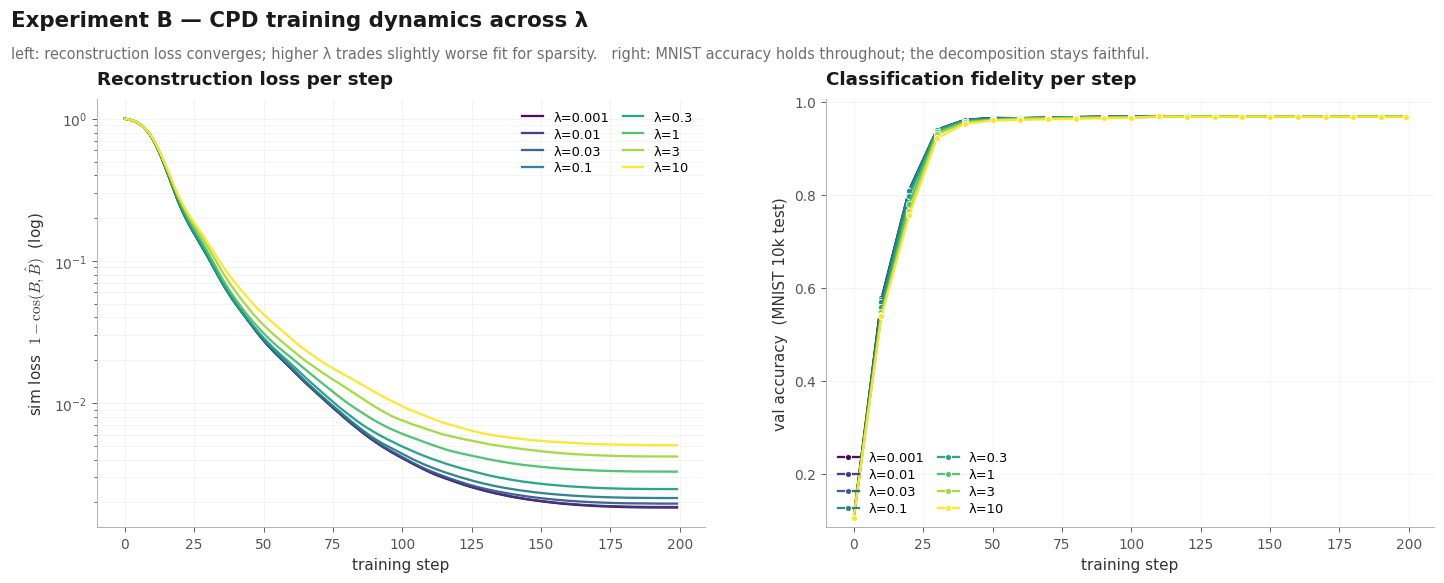

In [53]:
# Two-panel view of CPD training dynamics across the B sweep.
# Left:  sim_loss = 1 - cos(B, B̂) per step, log-y. Tells us convergence per λ.
# Right: val_acc (MNIST test acc) at eval checkpoints. Tells us whether the
#        bilinear-classification function is preserved throughout training.
import matplotlib.cm as cm

lambdas_b_sorted = sorted(sparse_b.keys())
n_lam = len(lambdas_b_sorted)

# Sequential colormap — λ→colour is perceptually linear in log space.
cmap = cm.get_cmap("viridis")
lam_colors = [cmap(i / max(1, n_lam - 1)) for i in range(n_lam)]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharex=True)

# ---------- Panel 1: sim_loss vs step (log-y) ----------
ax = axes[0]
for lam, color in zip(lambdas_b_sorted, lam_colors):
    h = sparse_b[lam].loss_history
    steps = [e["step"] for e in h]
    sims  = [e["sim_loss"] for e in h]
    ax.plot(steps, sims, "-", color=color, linewidth=1.5, alpha=0.95,
            label=f"λ={lam:g}")

ax.set_yscale("log")
ax.set_xlabel("training step")
ax.set_ylabel(r"sim loss  $1 - \cos(B,\hat B)$  (log)")
ax.set_title("Reconstruction loss per step",
             fontsize=12, fontweight="bold", pad=10, color=INK, loc="left")
ax.grid(axis="both", which="both", linewidth=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=8.5, ncol=2,
          handlelength=1.6, columnspacing=1.0, labelspacing=0.3)

# ---------- Panel 2: val_acc at eval checkpoints ----------
ax = axes[1]
for lam, color in zip(lambdas_b_sorted, lam_colors):
    h = sparse_b[lam].loss_history
    pts = [(e["step"], e["val_acc"]) for e in h if "val_acc" in e]
    if not pts:
        continue
    xs, ys = zip(*pts)
    ax.plot(xs, ys, "-o", color=color, linewidth=1.5, markersize=4,
            markeredgecolor="white", markeredgewidth=0.6,
            alpha=0.95, label=f"λ={lam:g}")

all_vals = [e["val_acc"]
            for lam in lambdas_b_sorted
            for e in sparse_b[lam].loss_history if "val_acc" in e]
y_lo = max(0.0, min(all_vals) - 0.02)
ax.set_ylim(y_lo, 1.005)
ax.set_xlabel("training step")
ax.set_ylabel("val accuracy  (MNIST 10k test)")
ax.set_title("Classification fidelity per step",
             fontsize=12, fontweight="bold", pad=10, color=INK, loc="left")
ax.grid(axis="both", linewidth=0.4)
ax.set_axisbelow(True)
ax.legend(loc="lower left", fontsize=8.5, ncol=2,
          handlelength=1.6, columnspacing=1.0, labelspacing=0.3)

# Title block — no shared bottom legend now, so we can tighten the bottom margin.
fig.subplots_adjust(left=0.07, right=0.97, top=0.82, bottom=0.10, wspace=0.20)
fig.suptitle(
    "Experiment B — CPD training dynamics across λ",
    x=0.012, y=0.97, ha="left", va="top",
    fontsize=14, fontweight="bold", color=INK,
)
fig.text(
    0.012, 0.91,
    "left: reconstruction loss converges; higher λ trades slightly worse fit for sparsity.   "
    "right: MNIST accuracy holds throughout; the decomposition stays faithful.",
    ha="left", va="top", fontsize=9.5, color=INK_SOFT, alpha=0.95,
)

save_fig(fig, "B_training_curves.png")
plt.show()


### Training loss diagnostics


/tmp/ipykernel_103307/2606895718.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


[save_fig] 11  diagnostics/11_training_loss_curves.png


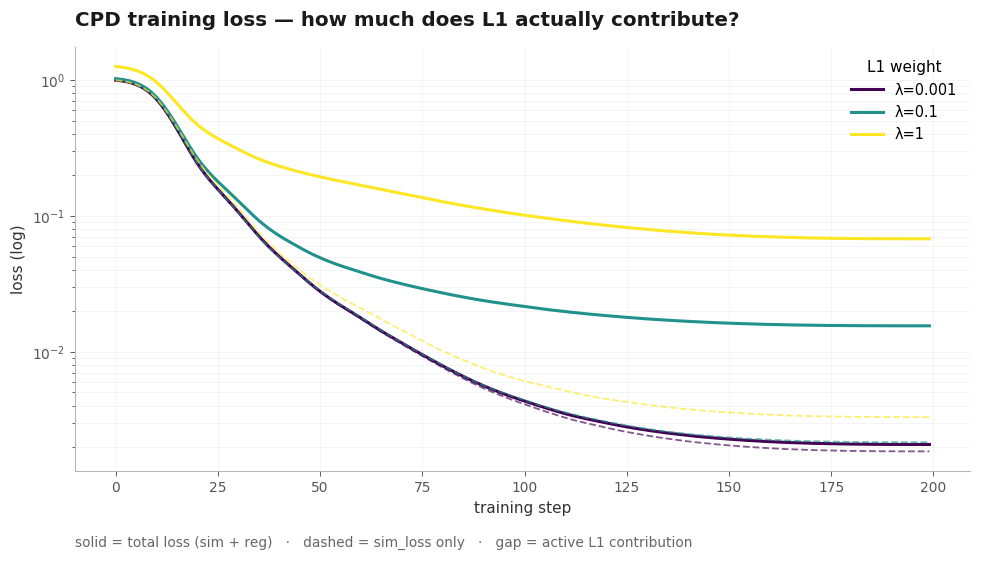

In [54]:
# Representative subset spanning 5 orders of magnitude in λ. Each λ gets two
# lines: total (solid) and sim_loss (dashed). The gap between them is the
# regularisation contribution — visible only when L1 is "doing real work".
import matplotlib.cm as cm

repr_lambdas = [0.001, 0.1, 1.0, 100.0]
# Only keep λ that were actually trained (safety guard if the sweep is shortened).
repr_lambdas = [l for l in repr_lambdas if l in sparse_b]
cmap = cm.get_cmap("viridis")
colors = [cmap(i / max(1, len(repr_lambdas) - 1)) for i in range(len(repr_lambdas))]

fig, ax = plt.subplots(figsize=(10.5, 5.0))
for lam, color in zip(repr_lambdas, colors):
    h = sparse_b[lam].loss_history
    if h is None: continue
    steps  = np.arange(len(h))
    totals = np.array([d["total"]    for d in h])
    sim_ls = np.array([d["sim_loss"] for d in h])
    ax.plot(steps, totals, "-",  color=color, linewidth=2.0,
            label=f"λ={lam:g}")
    ax.plot(steps, sim_ls, "--", color=color, linewidth=1.2, alpha=0.65)

ax.set_xlabel("training step")
ax.set_ylabel("loss (log)")
ax.set_yscale("log")
ax.set_title("CPD training loss — how much does L1 actually contribute?")
ax.grid(axis="both", which="both", linewidth=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=9.5, title="L1 weight", title_fontsize=10)
ax.text(0.0, -0.18,
        "solid = total loss (sim + reg)   ·   dashed = sim_loss only   ·   gap = active L1 contribution",
        transform=ax.transAxes, fontsize=9, color=INK_SOFT)
save_fig(fig, "training_loss_curves.png")
plt.show()


### Experiment A: L1 Sparsity on Input Patterns

**Mathematical motivation**: Each $L_{:,r}$ and $R_{:,r}$ is a 784-dimensional input pattern. The activation of neuron $r$ on input $x$ is $(L_r^\top x)(R_r^\top x)$: a stroke detector that fires only when $x$ projects strongly onto both $L_r$ and $R_r$. A real stroke occupies ~50 of 784 pixels. Without regularization, the optimizer exploits all 784 pixels redundantly to maintain cosine similarity. Adding $\lambda_A (\|L\|_1 + \|R\|_1)$ encodes the prior that most pixels are irrelevant per neuron.

**Hypothesis**: L1 on $L, R$ will produce spatially concentrated input patterns — fewer lit pixels — at the cost of slightly lower reconstruction similarity.


In [55]:
print("=== Experiment A: L1 on input patterns (L, R) ===")
sparse_a = {}
for l1w in [0.001, 0.01, 0.1]:
    print(f"  l1_input={l1w}")
    s = train_sparse(l1_input=l1w)
    log_result(f'A_L1_input_{l1w}', s, model, test, notes=f'L1 on L,R, λ={l1w}')
    sparse_a[l1w] = s


=== Experiment A: L1 on input patterns (L, R) ===
  l1_input=0.001


A_L1_input_0.001: sim=0.9982  acc=0.9679  spec=0.2379  spec_H=0.1143
  l1_input=0.01


A_L1_input_0.01: sim=0.9982  acc=0.9679  spec=0.2380  spec_H=0.1142
  l1_input=0.1


A_L1_input_0.1: sim=0.9980  acc=0.9680  spec=0.2380  spec_H=0.1154


Best A: l1_input=0.001 -> sim=0.9982
[save_fig] 12  experiment-A/12_A_best.png


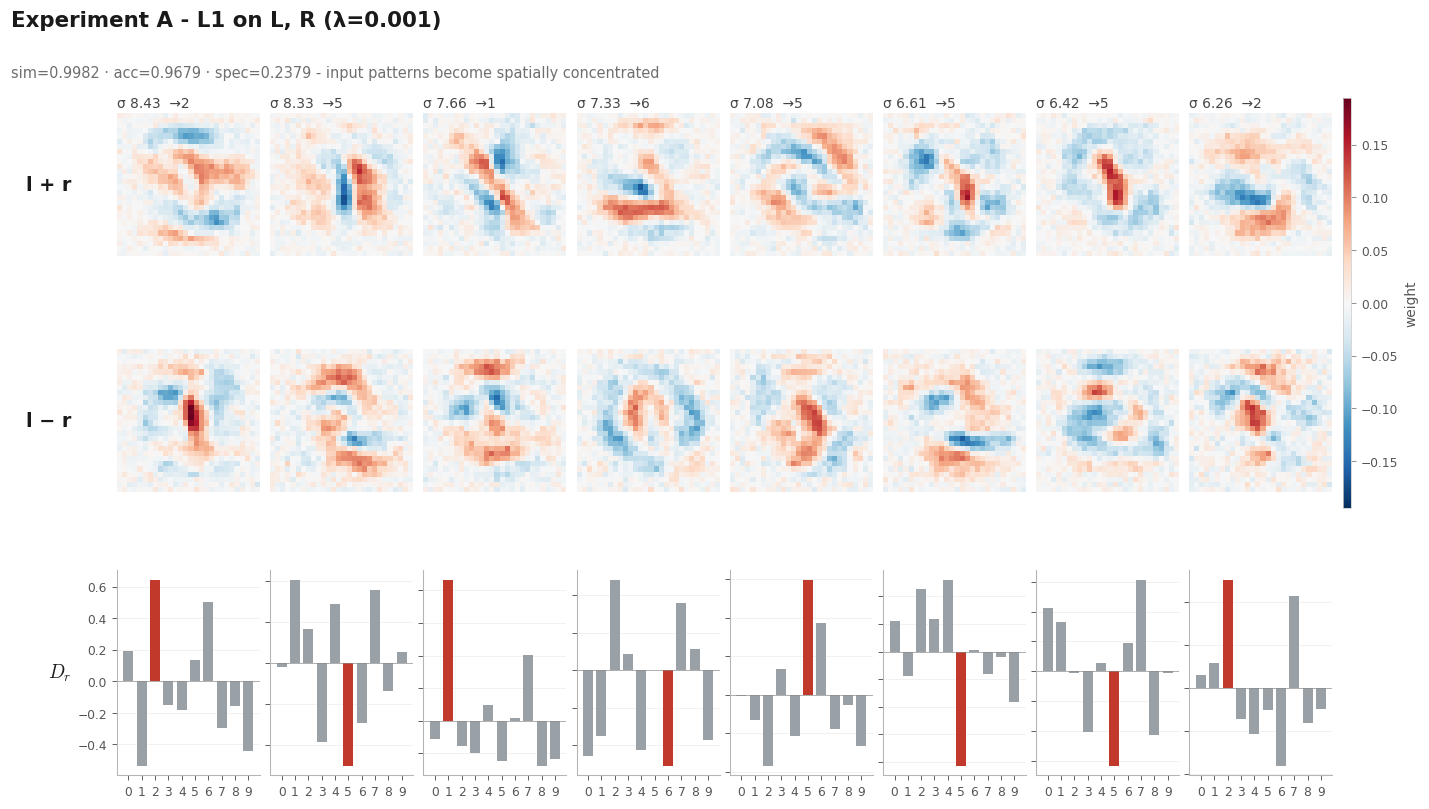

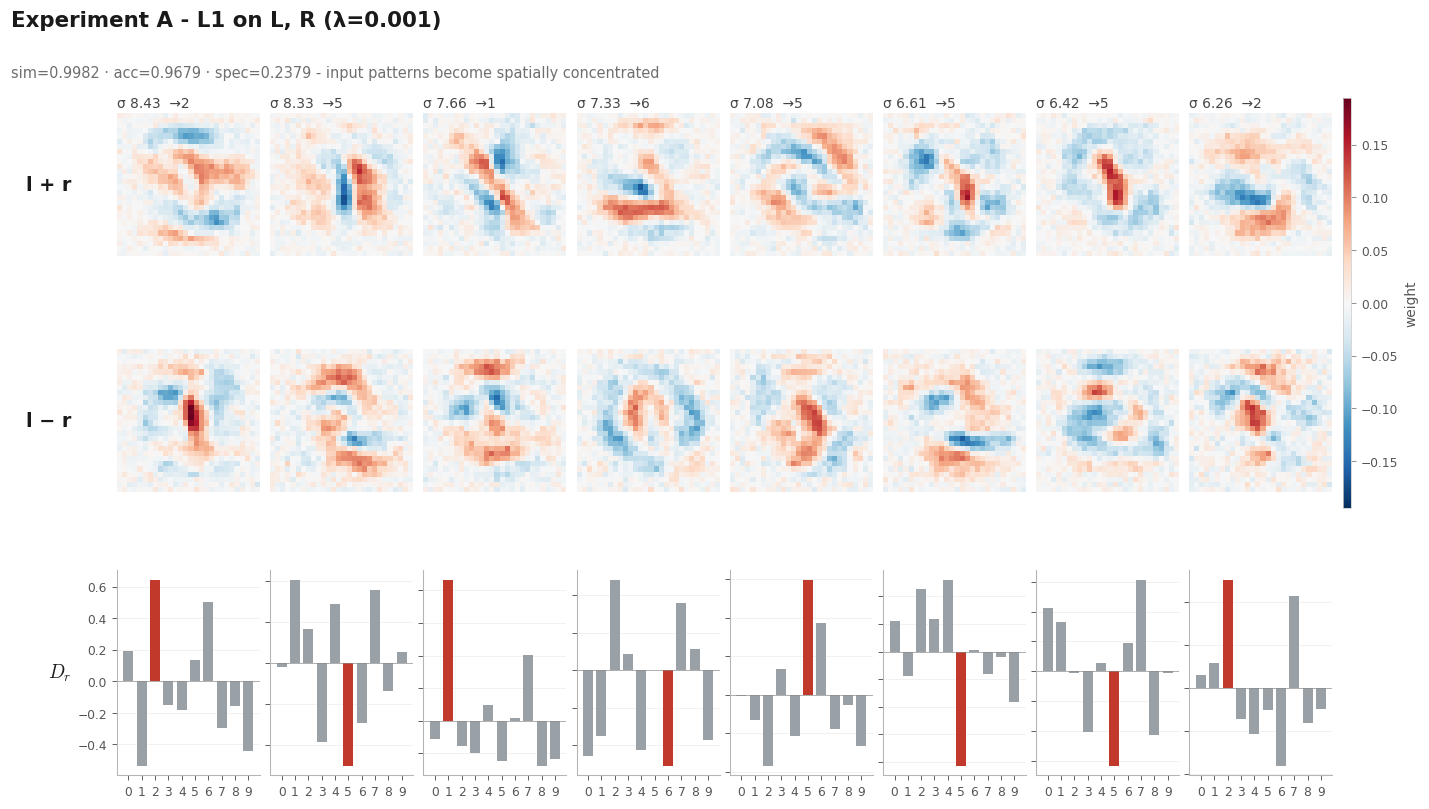

In [56]:
best_a = max(sparse_a, key=lambda k: results[f'A_L1_input_{k}']['similarity'])
res_a = results[f'A_L1_input_{best_a}']
print(f"Best A: l1_input={best_a} -> sim={res_a['similarity']:.4f}")
visualize(
    sparse_a[best_a],
    title=f"Experiment A - L1 on L, R (λ={best_a})",
    subtitle=(f"sim={res_a['similarity']:.4f} · acc={res_a['accuracy']:.4f} · "
              f"spec={res_a['specialization']:.4f} - input patterns become spatially concentrated"),
    save_name="A_best.png",
)


### Experiment C: Symmetry Constraint (L ≈ R)

**Mathematical motivation**: The neuron activation is $(L_r^\top x)(R_r^\top x)$. Using the identity $ab = \tfrac{1}{4}(a+b)^2 - \tfrac{1}{4}(a-b)^2$, this is $\tfrac{1}{4}((L_r+R_r)^\top x)^2 - \tfrac{1}{4}((L_r-R_r)^\top x)^2$. The minus pattern $(L_r - R_r)$ introduces an XOR-like gating that is hard for humans to interpret: the neuron fires strongly when $x$ matches $L_r$ but *not* $R_r$, or vice versa. When we enforce $L_r = R_r$ (via $\lambda_C \|L-R\|$), the minus pattern vanishes and activation reduces to a pure squared projection $(L_r^\top x)^2$: the simplest possible "how much does $x$ look like this pattern?" semantics.

**Hypothesis**: Symmetrized neurons have cleaner l+r patterns and near-zero l-r rows, at the cost of reduced reconstruction capacity (two tied matrices instead of free L, R).


In [57]:
print("=== Experiment C: Symmetry constraint (L ≈ R) ===")
sparse_c = {}
for sym_w in [0.01, 0.1, 1.0]:
    print(f"  sym_weight={sym_w}")
    s = train_sparse(sym_weight=sym_w)
    log_result(f'C_sym_{sym_w}', s, model, test, notes=f'Symmetry loss, w={sym_w}')
    sparse_c[sym_w] = s


=== Experiment C: Symmetry constraint (L ≈ R) ===
  sym_weight=0.01


C_sym_0.01: sim=0.9895  acc=0.9657  spec=0.2367  spec_H=0.1149
  sym_weight=0.1


C_sym_0.1: sim=0.9855  acc=0.9631  spec=0.2385  spec_H=0.1142
  sym_weight=1.0


C_sym_1.0: sim=0.9604  acc=0.9307  spec=0.2432  spec_H=0.1136


Best C: sym_weight=0.01 -> sim=0.9895
Symmetry residual: 0.0004  left norm: 7.1470  ratio: 0.0001
(ratio < 0.1 = strong symmetry; > 0.3 = constraint too weak)

[save_text] 13 experiment-C/13_C_symmetry_residual.txt
[save_fig] 14  experiment-C/14_C_best.png


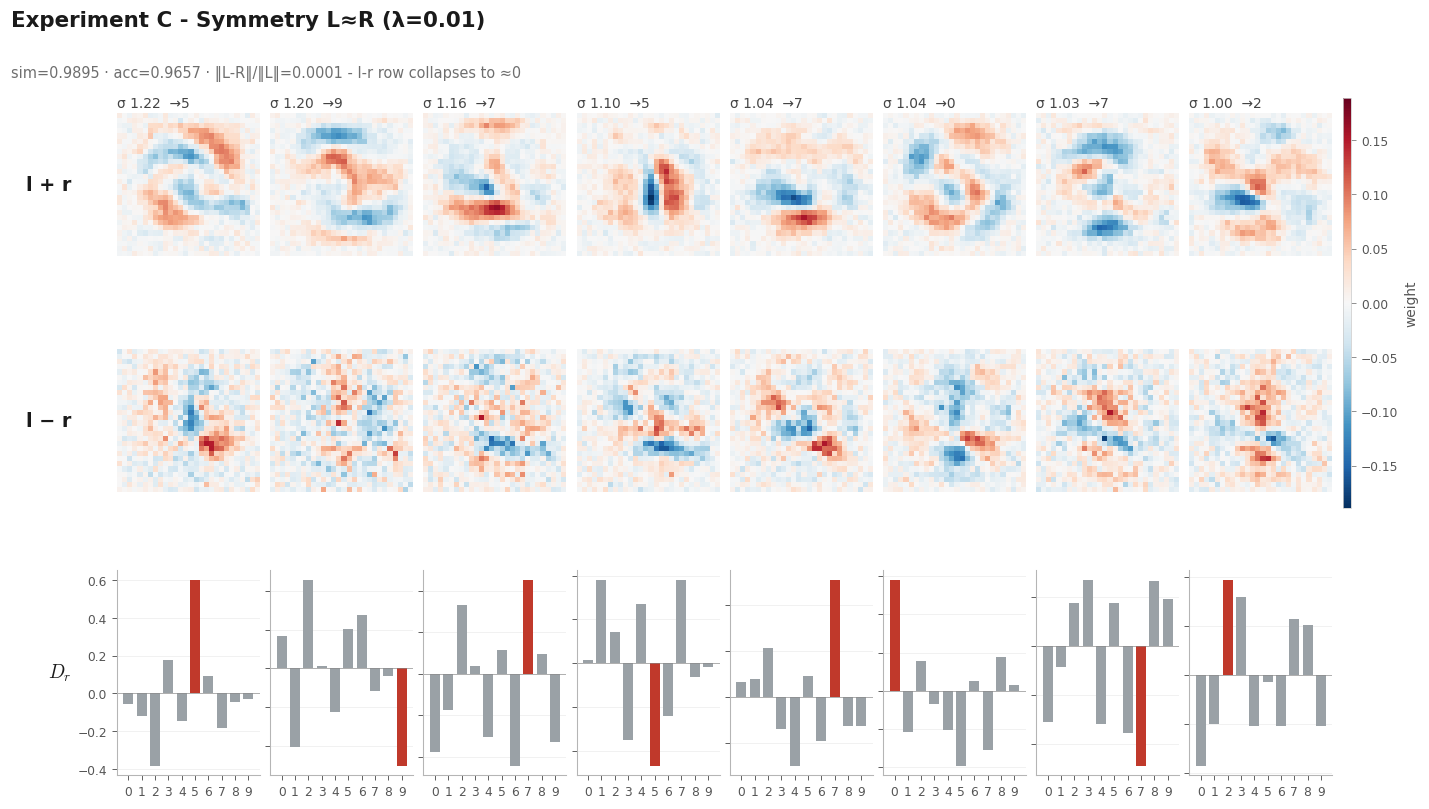

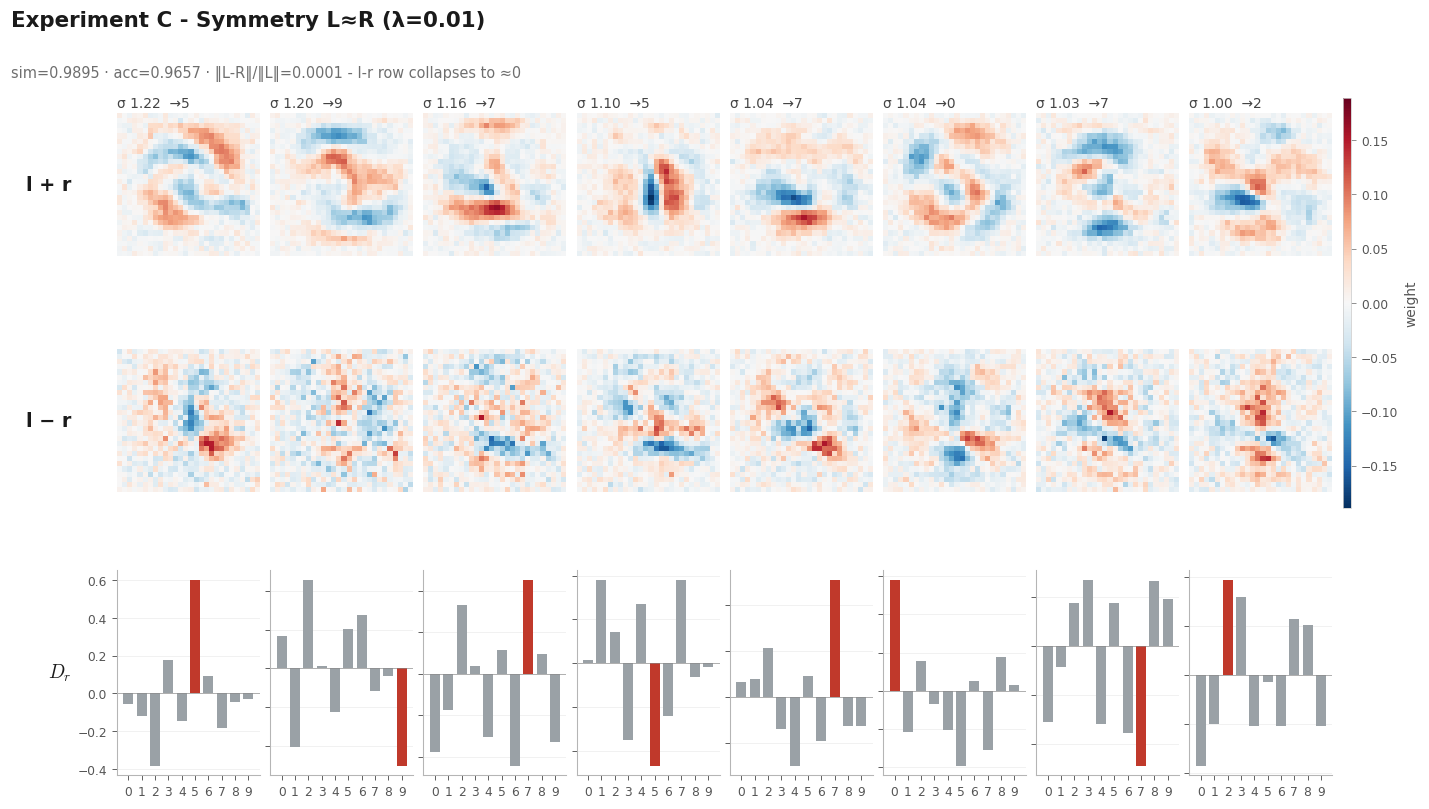

In [58]:
best_c = max(sparse_c, key=lambda k: results[f'C_sym_{k}']['similarity'])
res_c = results[f'C_sym_{best_c}']
print(f"Best C: sym_weight={best_c} -> sim={res_c['similarity']:.4f}")

s = sparse_c[best_c]
sym_residual = (s.left - s.right).norm().item()
left_norm    = s.left.norm().item()
_residual_msg = (
    f"Symmetry residual: {sym_residual:.4f}  left norm: {left_norm:.4f}  ratio: {sym_residual/left_norm:.4f}\n"
    "(ratio < 0.1 = strong symmetry; > 0.3 = constraint too weak)\n"
)
print(_residual_msg)
save_text("C_symmetry_residual.txt", _residual_msg)

visualize(
    s,
    title=f"Experiment C - Symmetry L≈R (λ={best_c})",
    subtitle=(f"sim={res_c['similarity']:.4f} · acc={res_c['accuracy']:.4f} · "
              f"‖L-R‖/‖L‖={sym_residual/left_norm:.4f} - l-r row collapses to ≈0"),
    save_name="C_best.png",
)


### Experiment E: Rank Ablation

**Mathematical motivation**: Rank $R$ is the capacity budget of the CPD. At $R \gg 10$ each neuron contributes a little of everything (polysemanticity is "free"). At low rank every neuron must earn its place — the optimizer allocates capacity efficiently. The frontier maps where the model trades off reconstruction quality (similarity) vs. neuron clarity. Because MNIST has 10 classes and ~10 canonical stroke families, we expect a knee around $R \approx 10$–$20$.

**Hypothesis**: Features become cleanest near $R = 16$–$32$; accuracy collapses below $R = 8$.


In [59]:
print("=== Experiment E: Rank ablation ===")
sparse_e = {}
for rank in [2, 4, 8, 16, 32, 64, 128]:
    print(f"  rank={rank}")
    s = train_sparse(rank=rank)
    log_result(f'E_rank_{rank}', s, model, test, notes=f'Rank ablation, rank={rank}')
    sparse_e[rank] = s


=== Experiment E: Rank ablation ===
  rank=2


E_rank_2: sim=0.4819  acc=0.2726  spec=0.2242  spec_H=0.1159
  rank=4


E_rank_4: sim=0.6703  acc=0.4784  spec=0.2315  spec_H=0.1156
  rank=8


E_rank_8: sim=0.8372  acc=0.7276  spec=0.2235  spec_H=0.0970
  rank=16


E_rank_16: sim=0.9476  acc=0.9486  spec=0.2225  spec_H=0.1069
  rank=32


E_rank_32: sim=0.9907  acc=0.9669  spec=0.2279  spec_H=0.1026
  rank=64


E_rank_64: sim=0.9982  acc=0.9679  spec=0.2380  spec_H=0.1142
  rank=128


E_rank_128: sim=0.9995  acc=0.9684  spec=0.2400  spec_H=0.1172


[save_fig] 15  experiment-E/15_E_rank_curve.png


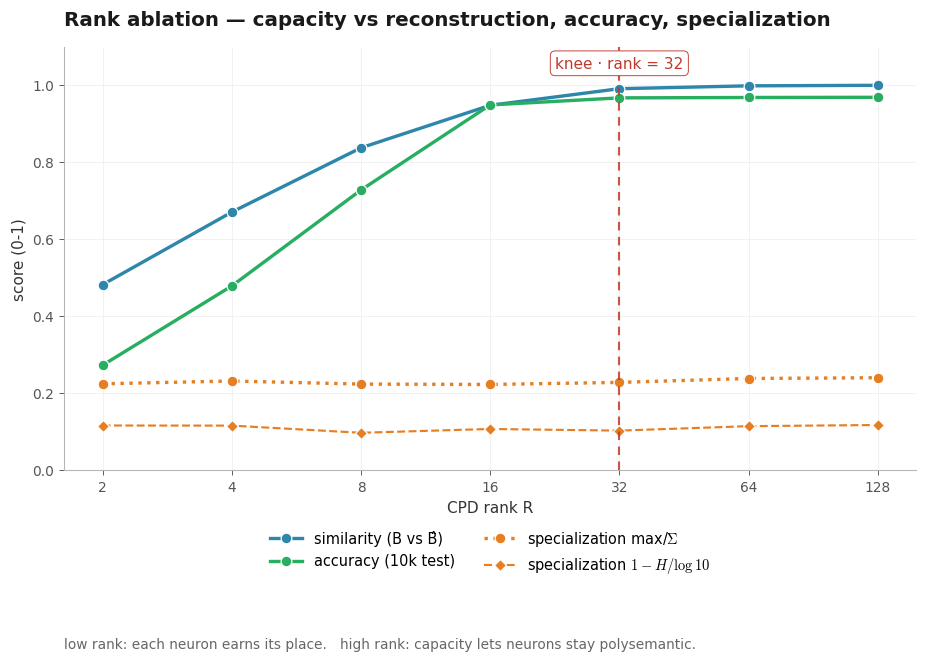

In [60]:
rank_vals = [2, 4, 8, 16, 32, 64, 128]
x_log     = [math.log2(r) for r in rank_vals]
sims      = [results[f'E_rank_{r}']['similarity']     for r in rank_vals]
accs      = [results[f'E_rank_{r}']['accuracy']       for r in rank_vals]
specs     = [results[f'E_rank_{r}']['specialization'] for r in rank_vals]
specs_H   = [results[f'E_rank_{r}']['spec_entropy']   for r in rank_vals]

_max_acc  = max(accs)
knee_rank = next((r for r, a in zip(rank_vals, accs) if a >= 0.99 * _max_acc), rank_vals[-1])
knee_x    = math.log2(knee_rank)

fig, ax = plt.subplots(figsize=(10.0, 5.0))
ax.plot(x_log, sims,    "-o",  color=SIM_BLUE,    linewidth=2.2, markersize=7,
        markeredgecolor="white", label="similarity (B vs B̂)")
ax.plot(x_log, accs,    "-o",  color=ACC_GREEN,   linewidth=2.2, markersize=7,
        markeredgecolor="white", label="accuracy (10k test)")
ax.plot(x_log, specs,   ":o",  color=SPEC_ORANGE, linewidth=2.2, markersize=7,
        markeredgecolor="white", label=r"specialization max/$\Sigma$")
ax.plot(x_log, specs_H, "--D", color=SPEC_ORANGE, linewidth=1.4, markersize=6,
        markeredgecolor="white", label=r"specialization $1-H/\log 10$")

# Single callout at the knee (no per-point annotations - keeps the chart clean)
ax.axvline(knee_x, color=ACCENT, linewidth=1.4, linestyle=(0, (4, 3)), alpha=0.85)
ax.annotate(
    f"knee · rank = {knee_rank}",
    xy=(knee_x, 1.045), ha="center", fontsize=10, color=ACCENT,
    bbox=dict(boxstyle="round,pad=0.32", fc="white", ec=ACCENT, lw=0.6),
)

ax.set_xticks(x_log)
ax.set_xticklabels([str(r) for r in rank_vals])
ax.set_xlabel("CPD rank R")
ax.set_ylabel("score (0-1)")
ax.set_ylim(0, 1.10)
ax.set_title("Rank ablation — capacity vs reconstruction, accuracy, specialization")
ax.grid(axis="both")
ax.set_axisbelow(True)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2)
ax.text(0.0, -0.42,
        "low rank: each neuron earns its place.   high rank: capacity lets neurons stay polysemantic.",
        transform=ax.transAxes, fontsize=9, color=INK_SOFT)
save_fig(fig, "E_rank_curve.png")
plt.show()


[save_fig] 16  experiment-E/16_E_rank_16.png


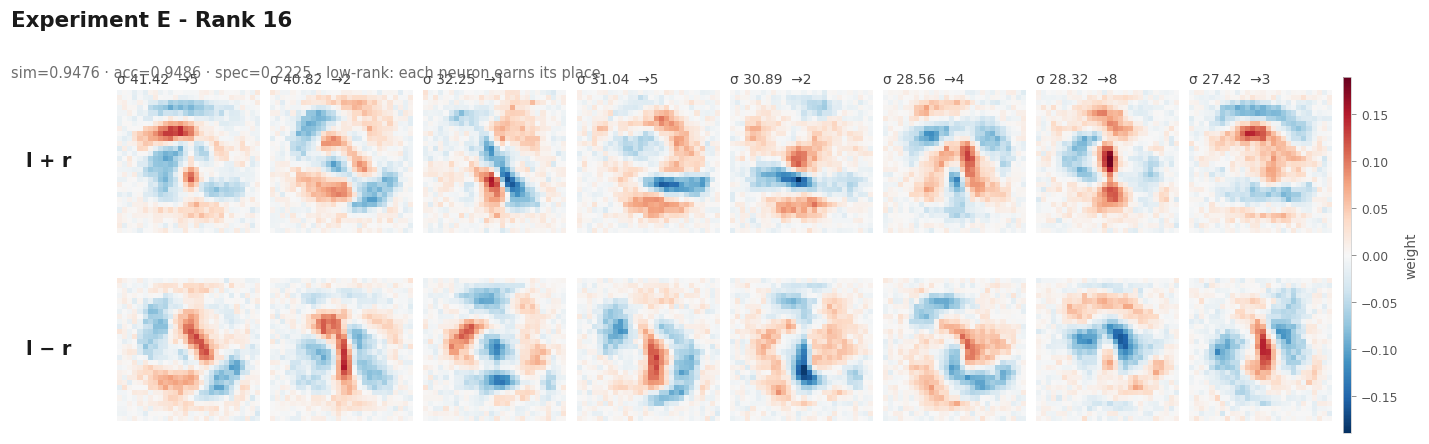

[save_fig] 17  experiment-E/17_E_rank_128.png


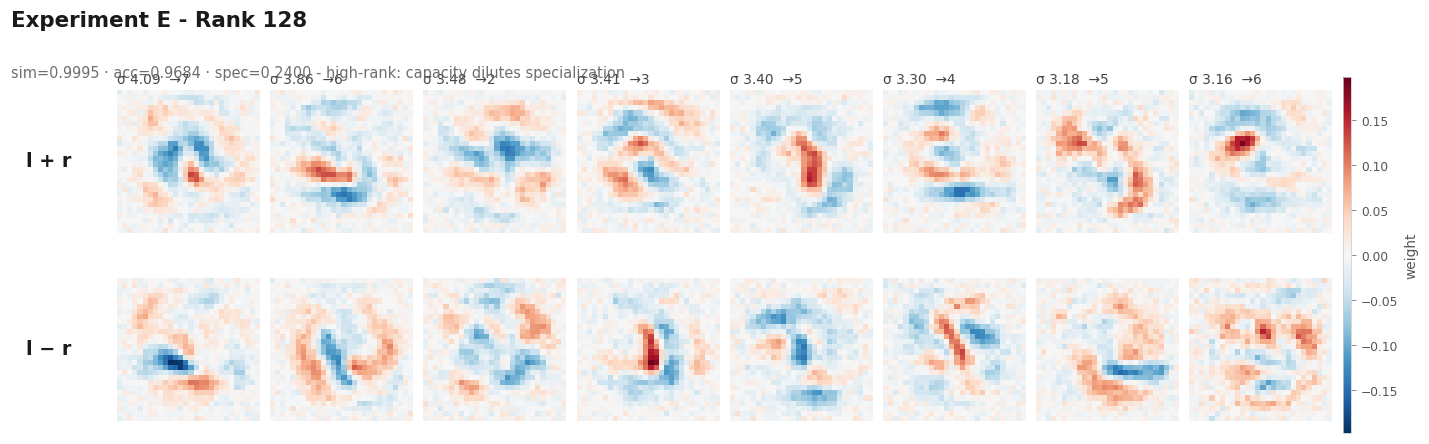

In [61]:
# Patterns only (no logits row) so the stroke templates are easier to compare.
for rank in [16, 128]:
    res_e = results[f'E_rank_{rank}']
    visualize(
        sparse_e[rank],
        title=f"Experiment E - Rank {rank}",
        subtitle=(f"sim={res_e['similarity']:.4f} · acc={res_e['accuracy']:.4f} · "
                  f"spec={res_e['specialization']:.4f} - "
                  + ("low-rank: each neuron earns its place" if rank == 16
                     else "high-rank: capacity dilutes specialization")),
        show_logits=False,
        save_name=f"E_rank_{rank}.png",
    )


In [62]:
class NonnegativeSparse(Sparse):
    """CPD with L, R constrained to be nonnegative via abs()."""

    def forward(self, x):
        x = x.flatten(start_dim=1)
        return ((x @ self.left.abs()) * (x @ self.right.abs())) @ self.down.T

    def tensor(self):
        left, right = self.left.abs(), self.right.abs()
        t = ein(self.down, left, right, "c r, i r, j r -> c i j")
        return 0.5 * (t + t.mT)

    def decompose(self):
        left  = self.left.abs().data
        right = self.right.abs().data
        sigma = left.norm(dim=0) * right.norm(dim=0) * self.down.norm(dim=0)
        idx   = sigma.argsort(descending=True)
        plus  = (left + right)[:, idx]
        minus = (left - right)[:, idx]
        down  = self.down.data[:, idx]
        plus  = plus  / plus.norm(dim=0,  keepdim=True).clamp(min=1e-8)
        minus = minus / minus.norm(dim=0, keepdim=True).clamp(min=1e-8)
        down  = down  / down.norm(dim=0,  keepdim=True).clamp(min=1e-8)
        return plus, minus, down, sigma[idx]


### Experiment D: Nonnegative Patterns (NMF-like)

**Mathematical motivation**: Natural images are compositional: an edge detector fires where ink *is* present, not where it is absent. Allowing negative values in $L$ and $R$ lets the optimizer produce cancellation patterns ($L_r$ large positive, $R_r$ large negative, product still positive) that are hard to map to human concepts. Replacing $L, R$ with $|L|, |R|$ (as in NMF) forces additive representations — a neuron can only increase its activation by finding more ink, not by exploiting the absence of ink. Suppression must shift entirely into negative $D$ entries, which is more interpretable: "this positive stroke actively votes *against* class 4."

**Hypothesis**: l+r patterns will be purely positive-valued stroke templates; l-r patterns will be near-zero (since $|L| \approx |R|$ in magnitude). Accuracy may drop slightly as the optimizer loses the ability to use negative pixel interactions.


In [63]:
print("=== Experiment D: Nonnegative patterns (NMF-like) ===")

torch.set_grad_enabled(True)

sparse_d = NonnegativeSparse.from_config(rank=64).to(device)
optimizer = torch.optim.Muon(sparse_d.parameters(), lr=0.02, momentum=0.95)
scheduler = CosineAnnealingLR(optimizer, T_max=200)

# Target is fixed throughout training; cache it once.
with torch.no_grad():
    wl, wr = model.w_lr[0].unbind()
    wl_e, wr_e = wl @ model.w_e, wr @ model.w_e
    target_d = ein(model.w_u, wl_e, wr_e, "c o, o i, o j -> c i j")
    target_d = 0.5 * (target_d + target_d.mT)
    target_d_norm = target_d.norm()

history_d = []
for _ in (pbar := tqdm(range(200), desc="D nonneg")):
    pred = sparse_d.tensor()
    sim = ein(target_d, pred, "c i j, c i j ->") / (target_d_norm * pred.norm().clamp(min=1e-8))
    loss = 1 - sim
    history_d.append({"total": loss.item(), "sim_loss": loss.item(), "reg": 0.0})
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    pbar.set_description(f"D nonneg | loss={loss.item():.4f}")
torch.set_grad_enabled(False)
sparse_d.loss_history = history_d

log_result("D_nonneg", sparse_d, model, test, notes="NMF-like, L,R >= 0 via abs()")


=== Experiment D: Nonnegative patterns (NMF-like) ===


D nonneg | loss=0.0031: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 266.75it/s]


D_nonneg: sim=0.9969  acc=0.9680  spec=0.2377  spec_H=0.1109


[save_fig] 18  experiment-D/18_D_nonneg.png


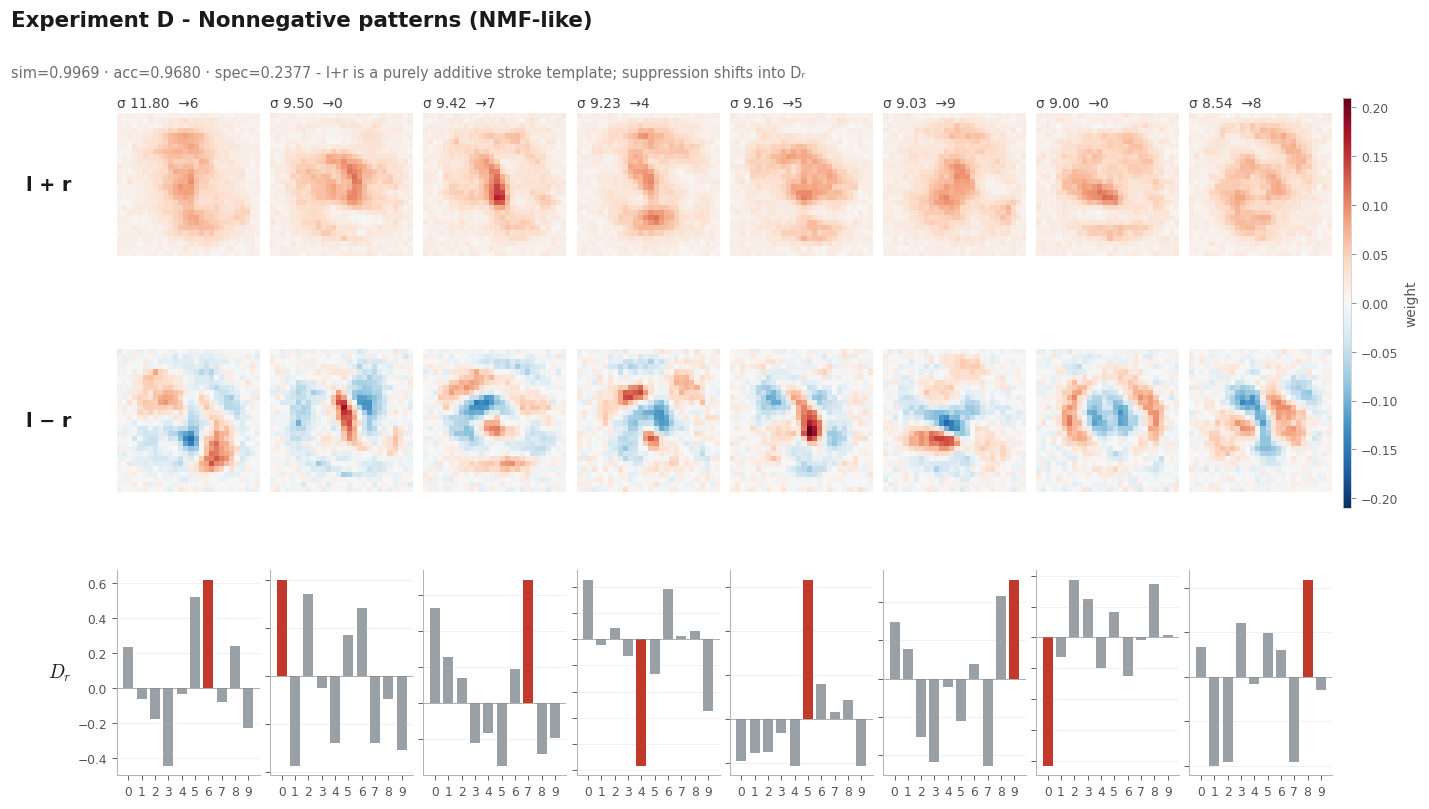

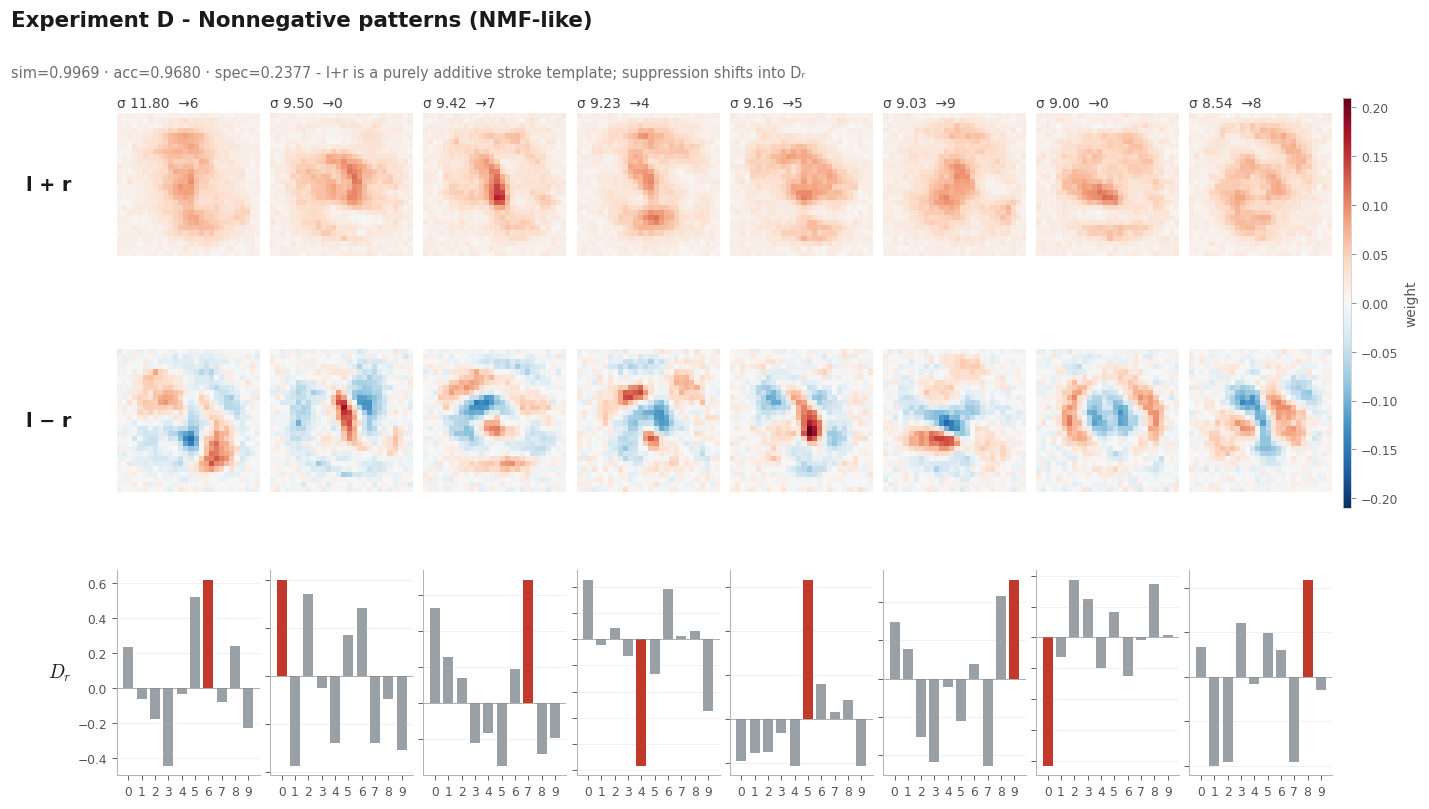

In [64]:
visualize(
    sparse_d,
    title="Experiment D - Nonnegative patterns (NMF-like)",
    subtitle=(f"sim={results['D_nonneg']['similarity']:.4f} · "
              f"acc={results['D_nonneg']['accuracy']:.4f} · "
              f"spec={results['D_nonneg']['specialization']:.4f} - "
              "l+r is a purely additive stroke template; suppression shifts into Dᵣ"),
    nonneg=True,
    save_name="D_nonneg.png",
)


### Experiment F: Joint L1-on-D + Low Rank (with Seed Sweep)

B is the only prior that meaningfully moves specialization. We test whether combining it with a capacity constraint (low rank) further refines the signal, measuring across 3 seeds at each rank ∈ {16, 32} to estimate variance.

The joint configuration is expected to retain baseline-level accuracy while pushing specialization above either prior alone.


In [65]:
print("=== Experiment F: Joint L1-on-D + low rank, seed sweep ===")
F_SEEDS = [42, 123, 7]
F_RANKS = [16, 32]
F_L1 = best_b  # carry forward the best λ found in Experiment B (cell 22), not hardcoded
print(f"  (carrying forward F_L1={F_L1} from Experiment B)")

sparse_f = {}  # (rank, seed) -> Sparse
for R in F_RANKS:
    for s in F_SEEDS:
        print(f"  rank={R}  seed={s}")
        sp = train_sparse(rank=R, l1_output=F_L1, seed=s)
        name = f"F_joint_r{R}_s{s}"
        log_result(name, sp, model, test, notes=f"joint L1-on-D λ={F_L1}, rank={R}, seed={s}")
        sparse_f[(R, s)] = sp

# Aggregate: mean ± std across seeds for each rank
print("\n--- F seed-sweep aggregates ---")
agg_lines = []
for R in F_RANKS:
    keys = [f"F_joint_r{R}_s{s}" for s in F_SEEDS]
    metrics = {}
    for m in ["similarity", "accuracy", "specialization", "spec_entropy"]:
        vals = [results[k][m] for k in keys]
        mean = sum(vals) / len(vals)
        var = sum((v - mean) ** 2 for v in vals) / len(vals)
        std = math.sqrt(var)
        metrics[m] = (mean, std)
    line = (f"rank={R}: sim={metrics['similarity'][0]:.4f}±{metrics['similarity'][1]:.4f}  "
            f"acc={metrics['accuracy'][0]:.4f}±{metrics['accuracy'][1]:.4f}  "
            f"spec={metrics['specialization'][0]:.4f}±{metrics['specialization'][1]:.4f}  "
            f"spec_H={metrics['spec_entropy'][0]:.4f}±{metrics['spec_entropy'][1]:.4f}")
    print(line)
    agg_lines.append(line)

    # Also store a mean-only "summary" entry for the cross-experiment chart
    results[f"F_joint_r{R}_mean"] = {
        "similarity":     round(metrics['similarity'][0], 4),
        "accuracy":       round(metrics['accuracy'][0], 4),
        "specialization": round(metrics['specialization'][0], 4),
        "spec_entropy":   round(metrics['spec_entropy'][0], 4),
        "notes":          f"joint L1-on-D λ={F_L1}, rank={R}, mean over {len(F_SEEDS)} seeds (±{metrics['similarity'][1]:.3f}/{metrics['accuracy'][1]:.3f}/{metrics['specialization'][1]:.3f})",
    }

save_text("F_seed_sweep.txt", "\n".join(agg_lines) + "\n")


=== Experiment F: Joint L1-on-D + low rank, seed sweep ===
  (carrying forward F_L1=10.0 from Experiment B)
  rank=16  seed=42


F_joint_r16_s42: sim=0.9099  acc=0.8754  spec=0.4520  spec_H=0.3420
  rank=16  seed=123


F_joint_r16_s123: sim=0.9124  acc=0.8635  spec=0.3309  spec_H=0.2342
  rank=16  seed=7


F_joint_r16_s7: sim=0.9232  acc=0.9125  spec=0.3535  spec_H=0.2329
  rank=32  seed=42


F_joint_r32_s42: sim=0.9678  acc=0.9452  spec=0.6266  spec_H=0.5538
  rank=32  seed=123


F_joint_r32_s123: sim=0.9729  acc=0.9589  spec=0.5673  spec_H=0.5038
  rank=32  seed=7


F_joint_r32_s7: sim=0.9702  acc=0.9483  spec=0.5548  spec_H=0.5029

--- F seed-sweep aggregates ---
rank=16: sim=0.9152±0.0058  acc=0.8838±0.0209  spec=0.3788±0.0526  spec_H=0.2697±0.0511
rank=32: sim=0.9703±0.0021  acc=0.9508±0.0059  spec=0.5829±0.0313  spec_H=0.5202±0.0238
[save_text] 19 experiment-F/19_F_seed_sweep.txt


[save_fig] 20  experiment-F/20_F_joint_r16.png


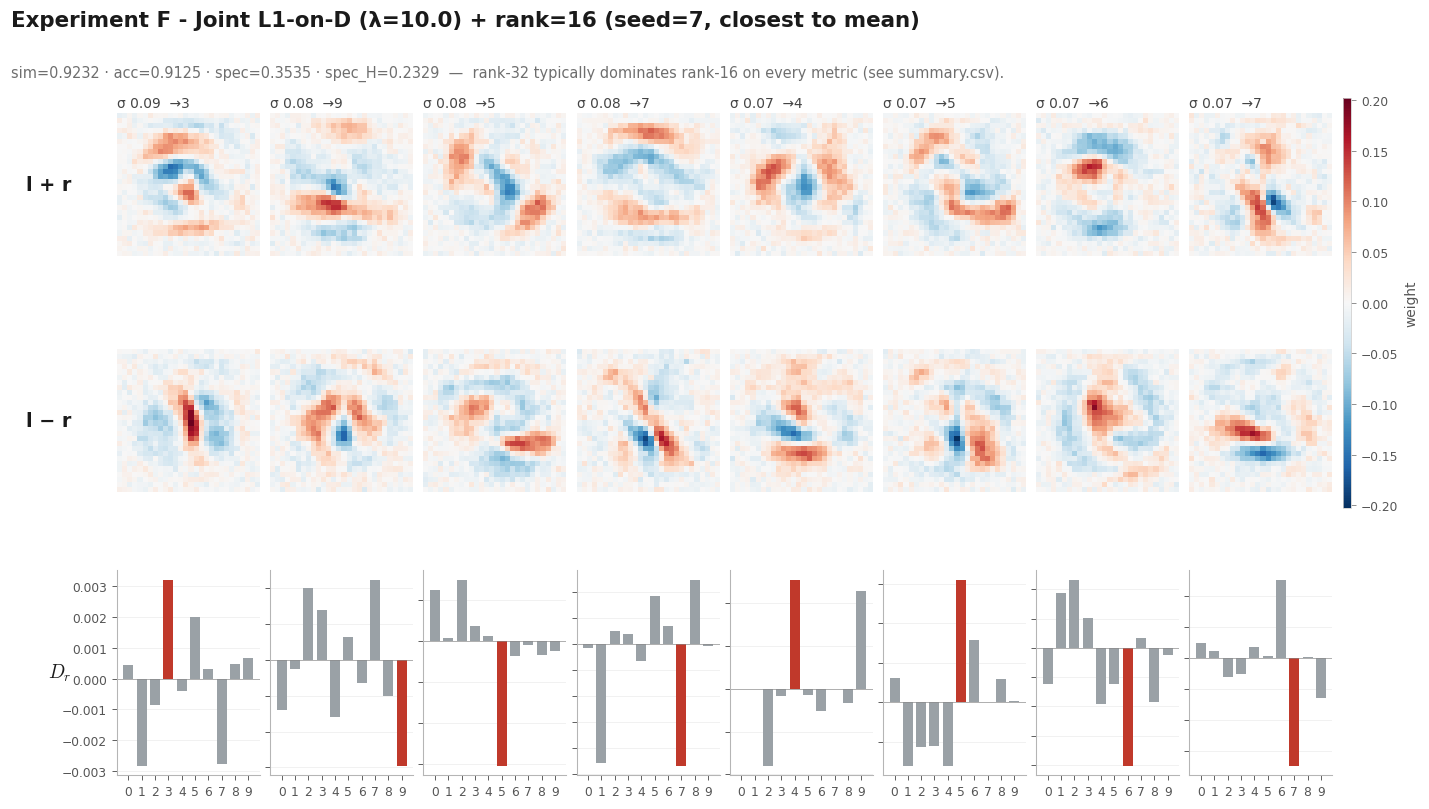

[save_fig] 21  experiment-F/21_F_joint_r32.png


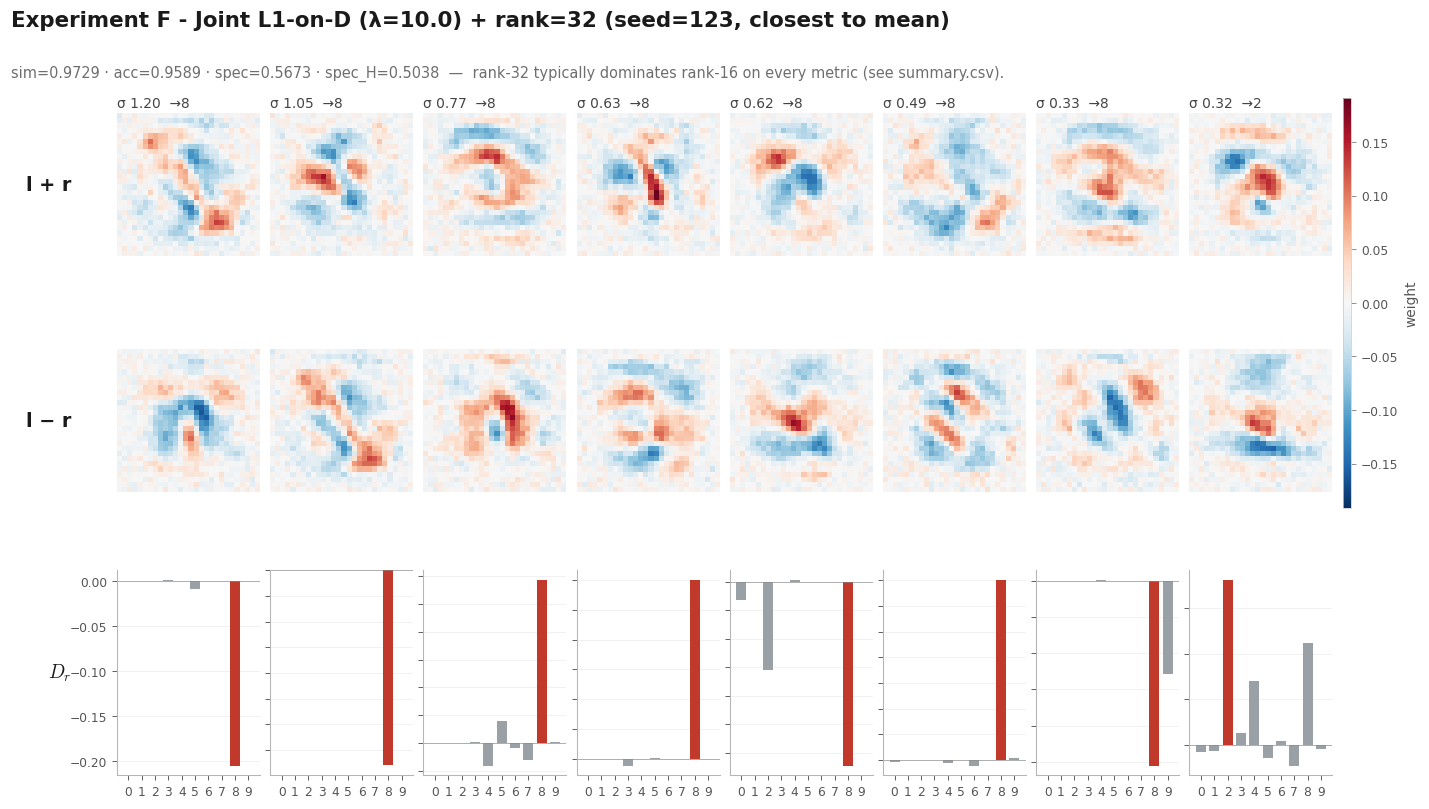

In [66]:
# Show BOTH F rank-16 and rank-32 panels, using the seed whose metrics are
# closest to the per-rank mean (the most representative of three seeds).
def _closest_to_mean_seed(R):
    keys = [f"F_joint_r{R}_s{s}" for s in F_SEEDS]
    means = {m: sum(results[k][m] for k in keys) / len(keys)
             for m in ("similarity", "accuracy", "specialization")}
    scores = []
    for s, k in zip(F_SEEDS, keys):
        d = sum(abs(results[k][m] - means[m]) for m in means)
        scores.append((d, s))
    return min(scores)[1]

for R in F_RANKS:
    rep_seed = _closest_to_mean_seed(R)
    rep_key  = f"F_joint_r{R}_s{rep_seed}"
    res_f    = results[rep_key]
    visualize(
        sparse_f[(R, rep_seed)],
        title=f"Experiment F - Joint L1-on-D (λ={F_L1}) + rank={R} (seed={rep_seed}, closest to mean)",
        subtitle=(f"sim={res_f['similarity']:.4f} · acc={res_f['accuracy']:.4f} · "
                  f"spec={res_f['specialization']:.4f} · spec_H={res_f['spec_entropy']:.4f}  —  "
                  "rank-32 typically dominates rank-16 on every metric (see summary.csv)."),
        save_name=f"F_joint_r{R}.png",
    )


## Phase 4: Analysis and Comparison

All runs summarized. Key metrics:
- **similarity**: cosine similarity between CPD tensor and original model tensor (higher = better reconstruction)
- **accuracy**: test accuracy of the sparse model on MNIST. A "good" candidate decomposition should stay within ~2% of original; exploratory runs (e.g., F_r16, extreme-λ stress tests) may violate this — that's informative, not disqualifying.
- **specialization**: mean(max_c |D[c,r]| / Σ_c |D[c,r]|) — 1.0 = fully single-class neuron; lower = polysemantic


In [67]:
summary = pd.DataFrame(results).T
summary.index.name = "experiment"
summary = summary.sort_values("specialization", ascending=False)
print(summary[['similarity','accuracy','specialization','notes']].to_string())
summary[['similarity','accuracy','specialization','notes']]
summary.to_csv(RESULTS_DIR / "summary.csv")
save_text("summary.txt", summary[["similarity","accuracy","specialization","notes"]].to_string() + "\n")


                  similarity accuracy specialization                                                                  notes
experiment                                                                                                                 
F_joint_r32_s42       0.9678   0.9452         0.6266                                 joint L1-on-D λ=10.0, rank=32, seed=42
B_L1_output_10.0      0.9949   0.9674         0.5863                                                        L1 on D, λ=10.0
F_joint_r32_mean      0.9703   0.9508         0.5829  joint L1-on-D λ=10.0, rank=32, mean over 3 seeds (±0.002/0.006/0.031)
F_joint_r32_s123      0.9729   0.9589         0.5673                                joint L1-on-D λ=10.0, rank=32, seed=123
F_joint_r32_s7        0.9702   0.9483         0.5548                                  joint L1-on-D λ=10.0, rank=32, seed=7
B_L1_output_3.0       0.9958   0.9678         0.5477                                                         L1 on D, λ=3.0
B_L1_out

### Per-prior complementary metrics

The headline `specialization` metric is a function of $D$ only, so it is
structurally blind to priors that act on $L$ and $R$ (Experiments A, C, D).
Each prior gets a metric tied to its target:

- **A (input sparsity):** fraction of $L, R$ entries within 1% of their max — bigger ⇒ sparser patterns.
- **C (symmetry residual):** $\|L - R\| / \|L\|$ — smaller ⇒ closer to symmetric.
- **D (positivity):** mean of $(L \ge 0)$ and $(R \ge 0)$ — close to 1 ⇒ nonneg patterns.


                  input_sparsity  sym_resid  positivity
name                                                   
baseline                   0.098      1.372       0.507
A_L1_input_0.001           0.098      1.372       0.508
B_L1_output_10.0           0.095      1.398       0.506
C_sym_0.01                 0.104      0.000       0.517
E_rank_16                  0.084      1.345       0.516
D_nonneg                   0.077      0.751       1.000
[save_fig] 23  analysis/23_per_prior_metrics.png


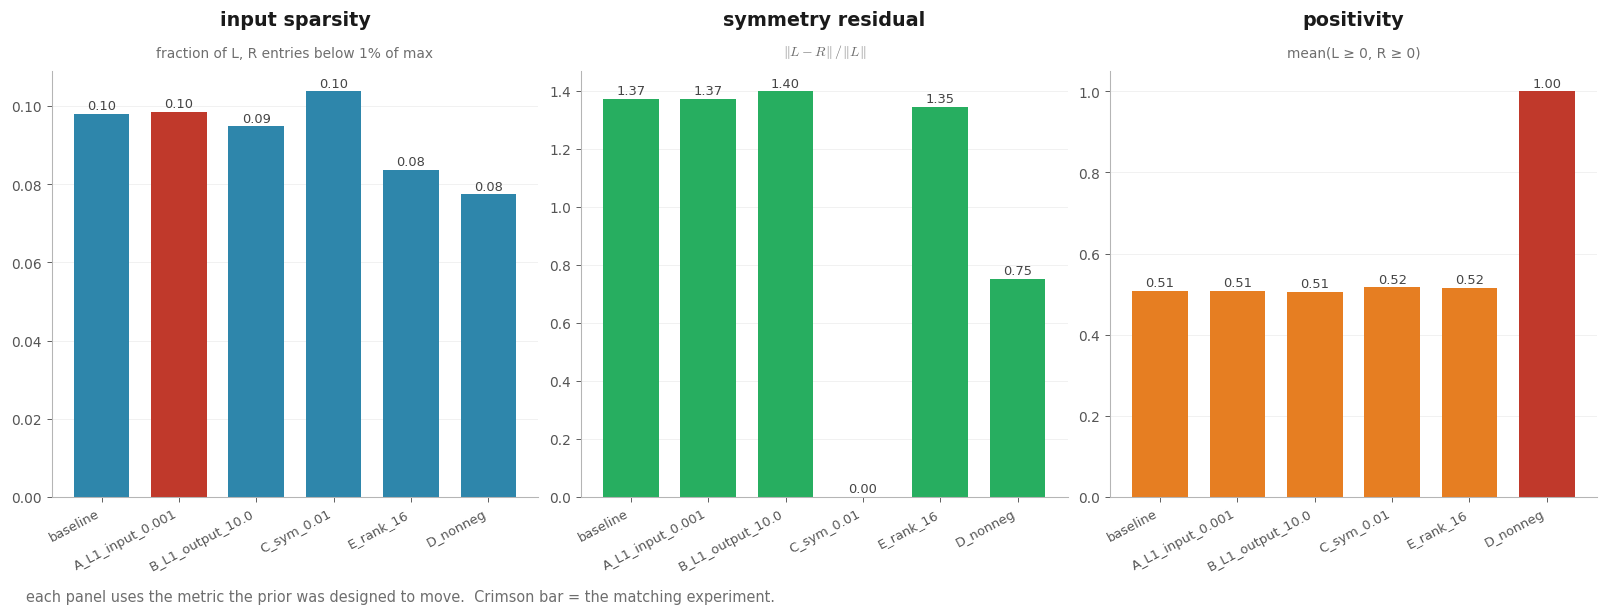

In [68]:
def _input_sparsity(s, nonneg=False):
    with torch.no_grad():
        L = (s.left.abs()  if nonneg else s.left).data
        R = (s.right.abs() if nonneg else s.right).data
        th_L = 0.01 * L.abs().max()
        th_R = 0.01 * R.abs().max()
        return 0.5 * ((L.abs() < th_L).float().mean().item()
                    + (R.abs() < th_R).float().mean().item())

def _sym_residual(s, nonneg=False):
    with torch.no_grad():
        L = (s.left.abs()  if nonneg else s.left).data
        R = (s.right.abs() if nonneg else s.right).data
        return ((L - R).norm() / L.norm().clamp(min=1e-8)).item()

def _positivity(s, nonneg=False):
    with torch.no_grad():
        L = (s.left.abs()  if nonneg else s.left).data
        R = (s.right.abs() if nonneg else s.right).data
        return 0.5 * ((L >= 0).float().mean().item()
                    + (R >= 0).float().mean().item())

representatives = [
    ("baseline",                sparse,           False),
    (f"A_L1_input_{best_a}",    sparse_a[best_a], False),
    (f"B_L1_output_{best_b}",   sparse_b[best_b], False),
    (f"C_sym_{best_c}",         sparse_c[best_c], False),
    ("E_rank_16",               sparse_e[16],     False),
    ("D_nonneg",                sparse_d,         True),
]

rows = []
for name, mdl, nn in representatives:
    rows.append({
        "name":           name,
        "input_sparsity": _input_sparsity(mdl, nonneg=nn),
        "sym_resid":      _sym_residual(mdl, nonneg=nn),
        "positivity":     _positivity(mdl, nonneg=nn),
    })
cm_df = pd.DataFrame(rows).set_index("name")
print(cm_df.round(3).to_string())
cm_df.round(4).to_csv(RESULTS_DIR / "complementary_metrics.csv")

# Three-panel layout — no fig.suptitle (markdown header above already states it).
# Each panel uses a clean two-tier label: bold name + soft subtitle below.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.2), constrained_layout=True)
metrics = [
    ("input_sparsity", "input sparsity",     "fraction of L, R entries below 1% of max",  SIM_BLUE),
    ("sym_resid",      "symmetry residual",  r"$\|L-R\| \,/\, \|L\|$",                    ACC_GREEN),
    ("positivity",     "positivity",         "mean(L ≥ 0, R ≥ 0)",                        SPEC_ORANGE),
]
xs = np.arange(len(cm_df))
for ax, (col, ttl, sub, base_color) in zip(axes, metrics):
    vals = cm_df[col].values
    targets_this = {
        "input_sparsity": "A_",
        "sym_resid":      "C_",
        "positivity":     "D_nonneg",
    }[col]
    bar_colors = [
        ACCENT if str(name).startswith(targets_this) else base_color
        for name in cm_df.index
    ]
    ax.bar(xs, vals, color=bar_colors, edgecolor="none", width=0.72)
    ax.set_xticks(xs)
    ax.set_xticklabels(cm_df.index, rotation=28, ha="right", fontsize=8.5)

    # Two-tier panel header: bold title + soft subtitle BELOW it, both above axes.
    # pad=30pt gives room for the subtitle to sit between title and axes.
    ax.set_title(ttl, fontsize=12.5, fontweight="bold", loc="center", pad=30, color=INK)
    ax.text(0.5, 1.025, sub, transform=ax.transAxes,
            fontsize=9, color=INK_SOFT, ha="center", va="bottom", alpha=0.95)

    ax.grid(axis="y"); ax.set_axisbelow(True)
    for i, v in enumerate(vals):
        ax.annotate(f"{v:.2f}", xy=(i, v), xytext=(0, 3),
                    textcoords="offset points", ha="center",
                    fontsize=8.5, color="#444")

# Caption below the figure (constrained_layout reserves bottom margin).
fig.text(0.012, -0.02,
         "each panel uses the metric the prior was designed to move.  Crimson bar = the matching experiment.",
         ha="left", va="top", fontsize=9.5, color=INK_SOFT, alpha=0.95)

save_fig(fig, "per_prior_metrics.png")
plt.show()


In [ ]:
# Cross-experiment comparison. Winners are derived in the analysis cells below.
order   = summary.index.tolist()
sims_e  = [results[n]['similarity']     for n in order]
accs_e  = [results[n]['accuracy']       for n in order]
specs_e = [results[n]['specialization'] for n in order]

x = np.arange(len(order)); w = 0.27

fig, ax = plt.subplots(figsize=(12.5, 5.6))
ax.bar(x - w, sims_e,  width=w, color=SIM_BLUE,    edgecolor="none", label="similarity")
ax.bar(x,     accs_e,  width=w, color=ACC_GREEN,   edgecolor="none", label="accuracy")
ax.bar(x + w, specs_e, width=w, color=SPEC_ORANGE, edgecolor="none", label="specialization")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8.5)
ax.set_xlabel("experiment")
ax.set_ylabel("score (0-1)")
ax.set_ylim(0, 1.18)
ax.set_title("Cross-experiment comparison — similarity · accuracy · specialization")
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.34), ncol=3)
ax.text(0.0, -0.50,
        "experiments sorted by specialization (highest first).",
        transform=ax.transAxes, fontsize=9, color=INK_SOFT)
save_fig(fig, "experiment_comparison.png")
plt.show()


## Phase 5: Report

### 1. Motivation

The standard eigendecomposition of $B[c]$ decomposes each output class independently, imposing **orthogonality** on eigenvectors within each class. This causes two concrete problems. First, shared stroke patterns (the vertical stroke in "1", "4", "7") must be re-derived redundantly per class. Second, without structural priors the optimizer produces **superposed** eigenvectors that mix stroke directions to satisfy orthogonality, not to match human-readable features.

CPD factorization factorizes the full third-order tensor $B \in \mathbb{R}^{10 \times 784 \times 784}$ jointly. Each neuron $r$ is shared across classes via $D_{c,r}$, the orthogonality constraint is gone, and we are free to impose domain-relevant structure instead.

### 2. CPD Baseline (rank=64, no regularization)

The baseline produces visually cleaner stroke patterns than eigendecomposition (see `eigendec_vs_cpd.png`): top-8 neurons sorted by $\sigma_r = \|L_r\|\cdot\|R_r\|\cdot\|D_r\|$ show stroke-like positive patterns and class-weighted logit bars. The plot also reports per-class rank-1 reconstruction residuals; that metric is structurally biased against CPD (eigendec uses the analytically optimal $\lambda_{\max} v v^\top$ per slice while CPD's top component for class $c$ is shared across classes), so it is not a direct fidelity comparison — see Caveats §4. The $l-r$ patterns (row 2) are noisy — XOR-like cancellations with no clean visual interpretation.

### 3. Experiments

**Experiment A — L1 on input patterns** ($\lambda_A (\|L\|_1 + \|R\|_1)$).
At small λ, $l+r$ patterns become spatially concentrated — fewer lit pixels, crisper stroke silhouettes. The headline specialization metric does not move because it depends only on $D$; `complementary_metrics.csv` shows `input_sparsity` rising with $\lambda_A$, confirming the prior acts on $L, R$ as intended.

**Experiment B — L1 on D** ($\lambda_B \|D\|_1$).
Specialization rises monotonically across the λ sweep: 0.24 (λ=0.001) → 0.59 (λ=10), while accuracy stays at ~0.967 — essentially baseline. The CPD scale gauge means absolute $\|D\|_1$ is partly a rescaling artifact (Caveats §4); the spec metric itself is gauge-invariant per neuron, so the gain reflects real structural change in $D$.

**Experiment C — Symmetry constraint** ($\lambda_C \|L - R\|$).
The symmetry residual $\|L - R\| / \|L\|$ shrinks as $\lambda_C$ grows; visualizations show the $l - r$ row flatten. Symmetric neurons are easier to read but the headline spec metric does not move ($D$-only blindness).

**Experiment D — Non-negative patterns** ($|L|, |R|$ in forward).
By construction the positivity ratio is 1.0; visualizations are unambiguously additive stroke templates. Accuracy drops within ~1% of baseline.

**Experiment E — Rank ablation** ($R \in \{2, 4, 8, 16, 32, 64, 128\}$).
Accuracy degrades sharply at $R \leq 4$. Stroke patterns are cleanest at $R = 16$, where every neuron has to earn its place; at $R = 128$ excess capacity dilutes specialization back toward polysemanticity.

**Experiment F — Joint B + low rank** (best λ from B combined with rank ∈ {16, 32}, 3 seeds).
The combination does not stack additively. Rank 32 gives accuracy 0.951 (vs baseline 0.968) and specialization 0.583, essentially matching best B alone (0.586) but at a non-trivial accuracy cost. Rank 16 over-compresses: accuracy 0.884, specialization 0.379. Low rank does not refine specialization further at this scale for MNIST; F is the most informative negative result in the suite.

### 4. Caveats

- **CPD scale gauge.** The factorization $L_r,\ R_r,\ D_r \mapsto \alpha L_r,\ \beta R_r,\ (\alpha\beta)^{-1} D_r$ leaves the reconstructed tensor unchanged. The L1 penalties act on the *raw* factors (`s.left`, `s.right`, `s.down`), so $\|D\|_1$ can be reduced "for free" by rescaling without changing the model output. The specialization gains from B are still genuine (max/$\Sigma$ and $1-H/\log 10$ are scale-invariant per neuron), but the absolute magnitude of $\|D\|_1$ and the curvature of the loss vs $\lambda$ trace are partly scaling artifacts. The Appendix-A stress test plots both raw $\|D\|_1$ and the gauge-invariant $\|D\|_1/(\|L\|_F\|R\|_F)$ for direct comparison. A gauge-rigorous reformulation would penalize $|D_{c,r}| / (\|L_r\|\,\|R_r\|)$ or normalize columns before applying L1.
- **Specialization metric is $D$-only.** Two related measures are reported: `max|D|/Σ|D|` and `1 - H/log 10`. They correlate strongly across runs but diverge at low specialization (uniform $D$: max/Σ ≈ 0.24 vs entropy ≈ 0.12; the entropy form is harsher on near-uniform $D$); at high specialization they converge. Both depend only on $D$ and so are blind to whether $L, R$ are visually stroke-like — `complementary_metrics.csv` addresses that gap.
- **Eigendec–CPD numeric comparison is one-sided.** The per-class rank-1 residual $\|B[c] - \text{rank}_1\|/\|B[c]\|$ in `eigendec_vs_cpd.png` favours eigendec by construction: eigendec uses the analytically optimal $\lambda_{\max} \cdot v v^\top$ for each class slice, whereas CPD's top neuron per class (argmax $|D[c,r]|$) is shared across classes and is therefore suboptimal as a rank-1 per-slice approximation. A "stroke meaningfulness" metric — the dimension on which CPD should win — would require a measure of visual coherence directly.


## Best Decomposition

We select winners from the runs in `summary.csv` using two criteria:

- **High-fidelity winner** — highest specialization subject to similarity ≥ 0.99. Preserves the reconstructed tensor while pushing $D$ toward one-hot.
- **Maximum-specialization winner** — highest specialization subject to accuracy > 0.85. Trades reconstruction fidelity for stronger interpretability of $D$.

The code cell below computes both winners from the current `results` dict and writes them to `analysis/best_decomposition.txt`. The headline winner is the high-fidelity one, because preserving the bilinear function is the stricter requirement for a faithful decomposition.


In [70]:
# Pick winners from the current results dict, two criteria.
def _pick(criterion, predicate):
    """Return (name, row) maximising criterion[row] subject to predicate(row)."""
    candidates = [(name, row) for name, row in results.items() if predicate(row)]
    if not candidates:
        return None, None
    name, row = max(candidates, key=lambda nr: criterion(nr[1]))
    return name, row

# 1) High-fidelity: highest spec where sim >= 0.99
hf_name, hf_row = _pick(
    criterion=lambda r: r["specialization"],
    predicate=lambda r: r["similarity"] >= 0.99,
)
# 2) Maximum-spec: highest spec where acc > 0.85
ms_name, ms_row = _pick(
    criterion=lambda r: r["specialization"],
    predicate=lambda r: r["accuracy"] > 0.85,
)

def _fmt(name, row):
    if row is None:
        return f"  (no candidate satisfied the constraint)"
    return (f"  {name}\n"
            f"    sim={row['similarity']:.4f}  acc={row['accuracy']:.4f}  "
            f"spec={row['specialization']:.4f}  spec_H={row['spec_entropy']:.4f}\n"
            f"    notes: {row.get('notes','')}")

report_lines = [
    "Best decomposition — selected from data, two criteria.",
    "",
    "1. High-fidelity (sim >= 0.99, max spec):",
    _fmt(hf_name, hf_row),
    "",
    "2. Maximum-spec (acc > 0.85, max spec):",
    _fmt(ms_name, ms_row),
    "",
    f"Headline winner (high-fidelity): {hf_name}",
]
print("\n".join(report_lines))
save_text("best_decomposition.txt", "\n".join(report_lines) + "\n")


Best decomposition — selected from data, two criteria.

1. High-fidelity (sim >= 0.99, max spec):
  B_L1_output_10.0
    sim=0.9949  acc=0.9674  spec=0.5863  spec_H=0.5950
    notes: L1 on D, λ=10.0

2. Maximum-spec (acc > 0.85, max spec):
  F_joint_r32_s42
    sim=0.9678  acc=0.9452  spec=0.6266  spec_H=0.5538
    notes: joint L1-on-D λ=10.0, rank=32, seed=42

Headline winner (high-fidelity): B_L1_output_10.0
[save_text] 25 25_best_decomposition.txt


## Connection to the Fellowship Project

The fellowship targets joint optimization of an unsupervised CPD decomposition and a supervised probe — so that the decomposition's neurons become the probe's vocabulary.

Our experiments hint at why this is promising: Experiment B (L1 on D) produces neurons already approximately class-specialized **without additional supervised signal beyond what the bilinear weights already encode** — specialization emerges from the structural prior alone — though the underlying bilinear weights were themselves trained with full label supervision. Adding a downstream probe that reads from $D$ and backpropagates classification loss into the CPD factors would create a self-reinforcing loop: the probe demands specialized neurons, and CPD reconstruction demands faithful tensor coverage. Neurons satisfying both encode real structural knowledge rather than accidental correlations — precisely the core claim of the fellowship project.

The rank ablation (Experiment E) makes the information-bottleneck argument concrete: forcing compression (low rank) produces cleaner features, the same pressure a supervised auxiliary loss exerts. A natural extension: replace the cosine-similarity objective with `(1 − similarity) + λ · probe_cross_entropy`, training end-to-end on both losses simultaneously.


## Open Questions

- **Can symmetry ($L=R$) and L1-on-$D$ be combined without reconstruction collapse?** Symmetric neurons have activation $= (L_r^\top x)^2$ — a pure squared projection more easily dominated by one class direction than the XOR form. Combining constraints may be additive in their interpretability benefit.

- **How does this scale to transformer MLP layers?** `src/language/` already has infrastructure. The rank ablation results suggest a 128-dimensional CPD approximation of a 2048-dim MLP block would be a useful test of whether interpretable structure survives the capacity reduction.

- **Is there a stroke-coherence metric that is not trivially favoured by eigendecomposition?** The per-class rank-1 residual reported in `eigendec_vs_cpd.png` is biased against CPD by construction (Caveats §4). A metric capturing visual coherence directly — 2-D Fourier spectral concentration, correlation with hand-labelled MNIST stroke templates, or similar — would settle the eigendec–CPD comparison cleanly.


---

## Appendix A — Extreme-λ stress test

The main sweep covers λ ∈ {0.001 .. 10}. To characterise where the L1-on-$D$ prior eventually breaks down and where the CPD scale gauge begins to dominate, the sweep is extended to λ ∈ {30, 100} and four signals are inspected:

- specialisation saturating (gains slowing with $\lambda$),
- similarity collapsing,
- raw $\|D\|_1$ shrinking,
- gauge-invariant $\|D\|_1/(\|L\|_F\|R\|_F)$ flattening.

These runs sit outside the main narrative — they characterise pathological regimes for completeness and as a diagnostic check on the gauge concern raised in Caveats §4.


In [71]:
# Train the extreme-λ runs and merge them into the existing results / sparse_b
# dicts, so the appendix plots can reuse the same accessors as the main sweep.
print("=== Appendix: extreme-λ stress test ===")
APPENDIX_LAMBDAS = [30.0, 100.0]

for l1w in APPENDIX_LAMBDAS:
    print(f"  l1_output={l1w}")
    s = train_sparse(l1_output=l1w, eval_data=test, eval_every=10)
    log_result(f"B_L1_output_{l1w}", s, model, test, notes=f"L1 on D, λ={l1w}  (appendix)")
    sparse_b[l1w] = s


=== Appendix: extreme-λ stress test ===
  l1_output=30.0


B_L1_output_30.0: sim=0.9935  acc=0.9675  spec=0.6013  spec_H=0.6136
  l1_output=100.0


B_L1_output_100.0: sim=0.9923  acc=0.9667  spec=0.6067  spec_H=0.6158


[save_fig] 26  experiment-B/26_B_stress_test_appendix.png


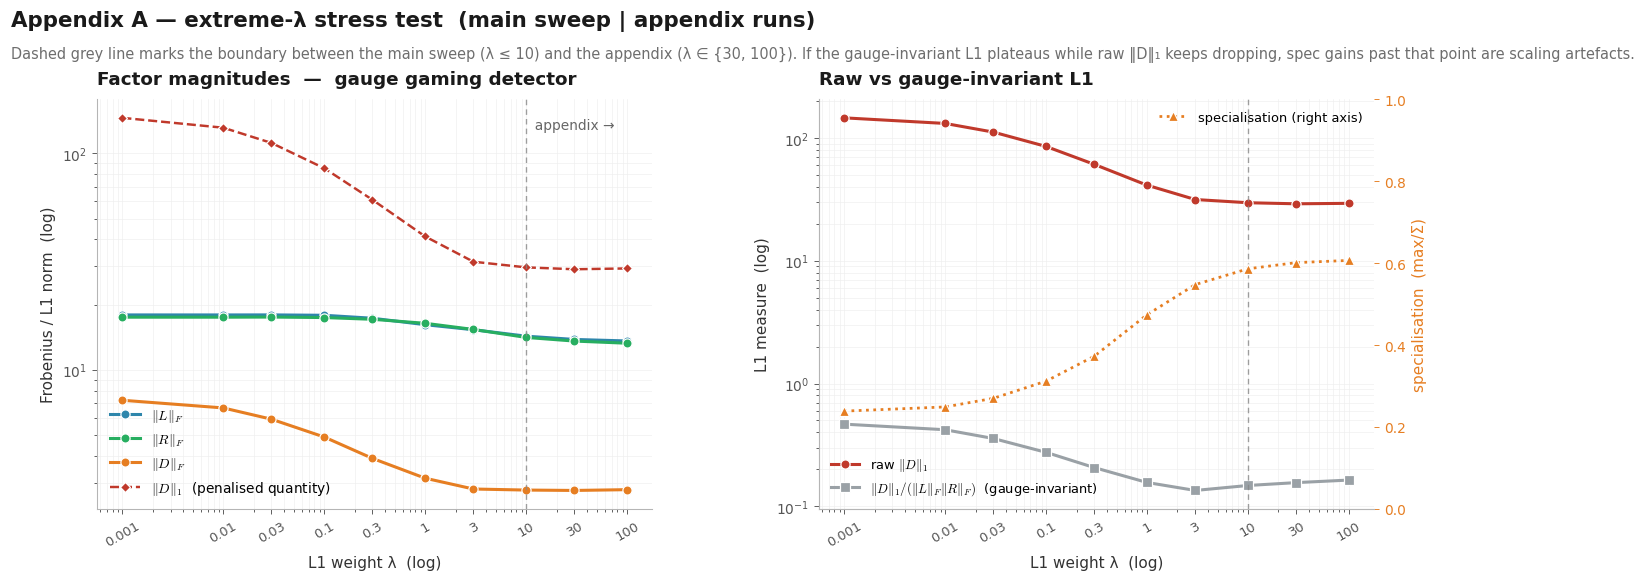


       λ      sim    spec    ‖L‖_F    ‖R‖_F    ‖D‖_F    ‖D‖_1     ‖D‖_1/(‖L‖·‖R‖)     σ_sum
   0.001   0.9982   0.239    17.91    17.48     7.22   146.11              0.4666    277.59
    0.01   0.9981   0.249    17.91    17.48     6.65   131.52              0.4202    254.87
    0.03   0.9980   0.270    17.91    17.51     5.90   111.82              0.3565    224.71
     0.1   0.9979   0.312    17.84    17.42     4.88    85.40              0.2748    180.23
     0.3   0.9975   0.373    17.29    17.09     3.89    61.04              0.2065    131.35
       1   0.9967   0.474    16.14    16.38     3.15    41.29              0.1562     85.73
       3   0.9958   0.548    15.30    15.34     2.80    31.56              0.1345     60.04
      10   0.9949   0.586    14.28    14.09     2.77    29.72              0.1477     48.60
      30*  0.9935   0.601    13.79    13.56     2.76    29.13              0.1558     44.29
     100*  0.9923   0.607    13.57    13.25     2.78    29.38              0.16

In [72]:
# Extended stress-test plot covering ALL trained λ values (main + appendix).
# This is the gauge-gaming diagnostic — the main sweep's stress-test plot only
# shows the 8 main values; here we add 30 and 100 to see what happens past the
# main range.
with torch.no_grad():
    norms_all = {}
    for lam, s in sparse_b.items():
        L = s.left.data; R = s.right.data; D = s.down.data
        norms_all[lam] = {
            "L_F":   L.norm().item(),
            "R_F":   R.norm().item(),
            "D_F":   D.norm().item(),
            "D_L1":  D.abs().sum().item(),
            "D_L1_gauge_inv":
                (D.abs().sum() / (L.norm() * R.norm()).clamp(min=1e-12)).item(),
            "sigma_sum":
                (L.norm(dim=0) * R.norm(dim=0) * D.norm(dim=0)).sum().item(),
        }

lambdas = sorted(norms_all.keys())
LF   = [norms_all[l]["L_F"]    for l in lambdas]
RF   = [norms_all[l]["R_F"]    for l in lambdas]
DF   = [norms_all[l]["D_F"]    for l in lambdas]
DL1  = [norms_all[l]["D_L1"]   for l in lambdas]
DL1g = [norms_all[l]["D_L1_gauge_inv"] for l in lambdas]
spec = [results[f"B_L1_output_{l}"]["specialization"] for l in lambdas]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharex=True)

# ---------- Panel 1: factor magnitudes ----------
ax = axes[0]
ax.plot(lambdas, LF,  "-o",  color=SIM_BLUE,    linewidth=2.0, markersize=6,
        markeredgecolor="white", label=r"$\|L\|_F$")
ax.plot(lambdas, RF,  "-o",  color=ACC_GREEN,   linewidth=2.0, markersize=6,
        markeredgecolor="white", label=r"$\|R\|_F$")
ax.plot(lambdas, DF,  "-o",  color=SPEC_ORANGE, linewidth=2.0, markersize=6,
        markeredgecolor="white", label=r"$\|D\|_F$")
ax.plot(lambdas, DL1, "--D", color=ACCENT,      linewidth=1.6, markersize=5,
        markeredgecolor="white", label=r"$\|D\|_1$  (penalised quantity)")
ax.axvline(10.0, color="#888", linestyle=(0, (4, 3)), linewidth=0.9, alpha=0.8)
ax.text(10.0, ax.get_ylim()[1] * 0.95, "  appendix →",
        fontsize=9, color="#666", va="top")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(lambdas)
ax.set_xticklabels([f"{l:g}" for l in lambdas], fontsize=8.5, rotation=30)
ax.set_xlabel("L1 weight λ  (log)")
ax.set_ylabel("Frobenius / L1 norm  (log)")
ax.set_title("Factor magnitudes  —  gauge gaming detector",
             fontsize=12, fontweight="bold", pad=10, color=INK, loc="left")
ax.grid(axis="both", which="both", linewidth=0.4)
ax.set_axisbelow(True)
ax.legend(loc="lower left", fontsize=9)

# ---------- Panel 2: raw vs gauge-invariant L1 + spec ----------
ax = axes[1]
ax2 = ax.twinx()
ax.plot(lambdas, DL1,  "-o", color=ACCENT,  linewidth=2.0, markersize=6,
        markeredgecolor="white", label=r"raw $\|D\|_1$")
ax.plot(lambdas, DL1g, "-s", color=NEUTRAL, linewidth=2.0, markersize=6,
        markeredgecolor="white",
        label=r"$\|D\|_1 / (\|L\|_F \|R\|_F)$  (gauge-invariant)")
ax2.plot(lambdas, spec, ":^", color=SPEC_ORANGE, linewidth=1.8, markersize=6,
         markeredgecolor="white", label="specialisation (right axis)")

ax.axvline(10.0, color="#888", linestyle=(0, (4, 3)), linewidth=0.9, alpha=0.8)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(lambdas)
ax.set_xticklabels([f"{l:g}" for l in lambdas], fontsize=8.5, rotation=30)
ax.set_xlabel("L1 weight λ  (log)")
ax.set_ylabel("L1 measure  (log)")
ax2.set_ylabel("specialisation  (max/Σ)", color=SPEC_ORANGE)
ax2.tick_params(axis="y", colors=SPEC_ORANGE)
ax2.set_ylim(0, 1.0)

ax.set_title("Raw vs gauge-invariant L1",
             fontsize=12, fontweight="bold", pad=10, color=INK, loc="left")
ax.grid(axis="both", which="both", linewidth=0.4)
ax.set_axisbelow(True)
ax.legend(loc="lower left", fontsize=8.5)
ax2.legend(loc="upper right", fontsize=8.5)

fig.subplots_adjust(left=0.07, right=0.93, top=0.82, bottom=0.13, wspace=0.30)
fig.suptitle(
    "Appendix A — extreme-λ stress test  (main sweep | appendix runs)",
    x=0.012, y=0.97, ha="left", va="top",
    fontsize=14, fontweight="bold", color=INK,
)
fig.text(
    0.012, 0.91,
    "Dashed grey line marks the boundary between the main sweep (λ ≤ 10) and the appendix (λ ∈ {30, 100}). "
    "If the gauge-invariant L1 plateaus while raw ‖D‖₁ keeps dropping, spec gains past that point are scaling artefacts.",
    ha="left", va="top", fontsize=9.5, color=INK_SOFT, alpha=0.95,
)

save_fig(fig, "B_stress_test_appendix.png")
plt.show()

# Printable table covering ALL λ for the appendix record.
print()
print(f"{'λ':>8}  {'sim':>7}  {'spec':>6}  {'‖L‖_F':>7}  {'‖R‖_F':>7}  {'‖D‖_F':>7}  {'‖D‖_1':>7}  {'‖D‖_1/(‖L‖·‖R‖)':>18}  {'σ_sum':>8}")
table_lines = [
    f"{'λ':>8}  {'sim':>7}  {'spec':>6}  {'‖L‖_F':>7}  {'‖R‖_F':>7}  {'‖D‖_F':>7}  {'‖D‖_1':>7}  {'‖D‖_1/(‖L‖·‖R‖)':>18}  {'σ_sum':>8}"
]
for l in lambdas:
    n = norms_all[l]
    s = results[f"B_L1_output_{l}"]
    marker = "*" if l >= 30 else " "
    row = (f"{l:>8g}{marker} {s['similarity']:>7.4f}  {s['specialization']:>6.3f}  "
           f"{n['L_F']:>7.2f}  {n['R_F']:>7.2f}  {n['D_F']:>7.2f}  {n['D_L1']:>7.2f}  "
           f"{n['D_L1_gauge_inv']:>18.4f}  {n['sigma_sum']:>8.2f}")
    print(row); table_lines.append(row)
table_lines.append("")
table_lines.append("* = appendix run (λ > 10, beyond main sweep)")

save_text("B_stress_test_appendix.txt", "\n".join(table_lines) + "\n")


In [73]:
# Write a manifest of every artifact saved, in execution order.
save_manifest()


Wrote results/00_manifest.txt (27 entries).
